## OCOM5203M Assignment 2 - Image Caption Generation [100 marks]

The maximum number of marks for each part are shown in the section headers. As indicated in the main heading above, the overall assessment carries a maximum of 100 marks.

This summative assessment is weighted 70% of the final grade for the module.

**Note:** This notebook includes two figures that are uploaded on the assessment page for viewing and downloading. Ensure that these figures are stored in the same directory as the notebook so they render properly when you load it.

### Motivation

Through this coursework, you will:

> 1. Understand the principles of text pre-processing and vocabulary building.
> 2. Gain experience working with an image to text model.
> 3. Use and compare two different text similarity metrics for evaluating an image to text model, and understand evaluation challenges.


### Setup and resources

Having a GPU will speed up the image feature extraction process. You can use Google Colab to complete this assingment.

Please implement the coursework using Python and PyTorch (i.e., Keras and TensorFlow are **not** accepted).

This coursework will use a subset of the [COCO "Common Objects in Context" dataset](https://cocodataset.org/) for image caption generation. COCO contains 330K images, of 80 object categories, and at least five textual reference captions per image. Our subset consists of 5029 of these images, each of which has five or more different descriptions of the salient entities and activities, and we will refer to it as COCO_5029.

To download the data:

> 1. **Images**: download the zip file "coco_subset_images.zip (812MB)" [here](https://leeds365-my.sharepoint.com/:f:/g/personal/busmnom_leeds_ac_uk/EuAH3b6a4g9IjTNhroLLXPoB6ho6cwxYSNh885ZzrktYZA?e=QGSYpf).
> 2. **Reference captions**: on the COCO [download page](https://cocodataset.org/#download), download the file named "2017 Train/Val annotations (241MB)".
> 3. **Image meta data**: as our set is a subset of full COCO dataset, we have created a CSV file containing relevant meta data for our particular subset of images. You can download it also from Drive, "coco_subset_meta.csv" at the same link as 1.


### Submission

Please submit the following and use your student ID as file names:

> 1. Your completed Jupyter notebook file, in .ipynb format. Please do not submit the two pre-supplied figures. 
> 2. The .html version of your notebook. **Check that all cells have been run** and all outputs (including all graphs you would like to be marked) are displayed in the .html file for marking.
>

**Note 1:** You can download the HTML version of your notebook in Jupyter Notebook via `File > Download as > HTML (.html)`. If the HTML option is not available in Google Colab, download your `.ipynb` file and either open it in Jupyter Notebook to export as HTML (`File > Download as > HTML (.html)`) or use the command `jupyter nbconvert --to html my-notebook.ipynb`. Make sure to double check the generated file before submitting.

### Overall quality

Penalties for issues related to overall quality will be applied (up to a maximum of **5 marks**) if the submission does not meet the following standards:

- **Code Modularity:** The implementation should follow a clean, modular design, with well-structured functions and classes where appropriate, and minimal code duplication.
- **Readability:** Code should be clear and easy to follow, with meaningful variable names and concise, relevant comments.
- **Output Accessibility:** Outputs should be neatly formatted, clearly labelled, and easy to interpret, avoiding excessive or unnecessary information dumps.
- **Clarity of Visualisations:** Figures and plots should be clearly labelled (axes, legends, titles where appropriate) and suitable for interpretation without additional explanation.
- **Reproducibility:** Results should be reproducible when the code is re-run (e.g., by setting random seeds and documenting any sources of randomness).


Final note:

> **Please include in this notebook everything that you would like to be marked, including figures. Under each section, put the relevant code containing your solution. You may re-use functions you defined previously, but any new code must be in the relevant section.** Feel free to add as many code cells as you need under each section.

Enter your student ID in the cell below. Note that there may be a message on the Minerva submission page asking you to anonymise your submission. Please disregard that message and provide your ID below.

# Public portfolio edition


## Imports

Feel free to add to this section as needed.

In [1]:
import torch
import torch.nn as nn
from torchvision import transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import torch.optim as optim

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from PIL import Image
from tqdm import tqdm
import os
import re
import random

# For statistical analysis
from scipy import stats
from scipy.stats import pearsonr, spearmanr

# For BLEU score
import nltk
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

# Download Natural Language Toolkit data 
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Display settings
pd.set_option('display.precision', 4)
plt.style.use('seaborn-v0_8-whitegrid')

print("All imports successful!")

All imports successful!


In [ ]:

# Define Hyperparameters and Constants at outset

# Model Architecture
FEATURE_DIM = 2048      # ResNet-152 output dimension
EMBED_SIZE = 256        # Word embedding dimension
HIDDEN_SIZE = 512       # LSTM hidden state dimension
NUM_LAYERS = 2          # Number of LSTM layers
MAX_SEQ_LEN = 47        # Maximum caption length
DROPOUT = 0.3           # Dropout probability

# Training Configuration
BATCH_SIZE = 64         # Batch size for training
LEARNING_RATE = 0.001   # Initial learning rate
NUM_EPOCHS = 10          # Number of training epochs
GRAD_CLIP = 5.0         # Gradient clipping threshold

# Early Stopping
PATIENCE = 3            # Epochs to wait before early stopping

# Beam Search
BEAM_SIZES = [3, 4, 5]  # Beam sizes to experiment with
LENGTH_PENALTY_ALPHA = 0.7  # Length normalisation factor

# Vocabulary
MIN_WORD_FREQ = 3       # Minimum word frequency to include

print("Hyperparameters loaded:")
print(f"  Model: embed={EMBED_SIZE}, hidden={HIDDEN_SIZE}, layers={NUM_LAYERS}, dropout={DROPOUT}")
print(f"  Training: batch={BATCH_SIZE}, lr={LEARNING_RATE}, epochs={NUM_EPOCHS}")
print(f"  Beam search sizes to test: {BEAM_SIZES}")

Hyperparameters loaded:
  Model: embed=256, hidden=512, layers=2, dropout=0.3
  Training: batch=64, lr=0.001, epochs=10
  Beam search sizes to test: [3, 4, 5]


Detect which device (CPU/GPU) to use.

In [5]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print("Using device: CUDA (NVIDIA GPU)")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Using device: MPS (Apple Silicon / M-Series Chip)")
else:
    device = torch.device('cpu')
    print("Using device: CPU")

Using device: MPS (Apple Silicon / M-Series Chip)


The basic principle of our image-to-text model is as pictured in the diagram below, where an Encoder network encodes the input image as a feature vector by providing the outputs of the last fully-connected layer of a pre-trained CNN (we use [ResNet-152](https://arxiv.org/abs/1512.03385)). This pretrained network has been trained on the complete ImageNet dataset and is thus able to recognise common objects.

These features are then fed into a Decoder network along with the reference captions. As the image feature dimensions are large and sparse, the Decoder network includes a linear layer which downsizes them, followed by a batch normalisation layer to speed up training. Those resulting features, as well as the reference text captions, are passed into a recurrent network (we will use the RNN family of models).

The reference captions used to compute loss are represented as numerical vectors via an embedding layer whose weights are learned during training.

![Encoder Decoder](encoder_decoder_diagramv2022.png)

The Encoder-Decoder network could be coupled and trained end-to-end, without saving features to disk; however, this requires iterating through the entire image training set during training. We can make the training more efficient by decoupling the networks.

We will first extract the feature representations of the images from the Encoder and save them on disk (Part 1). During training of the Decoder (Part 3), we only need to iterate over the image feature data and the reference captions.

### Organisation of the Notebook

> 1. Extracting image features [4 marks]
> 2. Text preparation [10 marks]
> 3. Train DecoderRNN [25 marks]
> 4. Generate predictions on test data [12 marks]
> 5. Caption length statistics and analysis [6 marks]
> 6. Caption evaluation using BLEU score [8 marks]
> 7. Caption evaluation using cosine similarity [12 marks]
> 8. Comparing BLEU and Cosine similarity [23 marks]



## 1 Extracting image features [4 marks]

### 1.1 EncoderCNN

Read through the template EncoderCNN class below and complete the class.

In [3]:
class EncoderCNN(nn.Module):
    def __init__(self):
        """Load a pretrained CNN and remove the top fully connected (fc) layer."""
        super(EncoderCNN, self).__init__()
        

        # 1. Load the ResNet-152 pretrained model.
        resnet = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V1)
        # 2. Keep all layers except the final classification layer.
        modules = list(resnet.children())[:-1] 
        self.resnet = nn.Sequential(*modules) 

    def forward(self, images):
        """Extract feature vectors from input images."""
        
        # 1. Disable gradients for the forward pass through the CNN.
        with torch.no_grad():
        # 2. Pass the images through the modified network.
            features = self.resnet(images)
        
        features = features.view(features.size(0), -1) # flatten the features (batch, 2048,1,1) -> (batch, 2048)
        
        # 3. Return the extracted features.
        return features


EncoderCNN: turns an image into a list of 2048 numbers that represent the visual content of that image.

DecoderRNN: takes the list of 2048 numbers and turns it into a list of words that represent the caption of that image.  

In [6]:
# instantiate encoder and put into evaluation mode.
encoder = EncoderCNN().to(device)
encoder.eval()

EncoderCNN(
  (resnet): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(64

In [7]:
# Test the encoder with a random image tensor
random_image = torch.randn(1, 3, 224, 224).to(device)
features_test = encoder(random_image)
print('Extracted features shape:', features_test.shape)  # Expected output: (1, 2048)

Extracted features shape: torch.Size([1, 2048])


Results confirm:

- The model accepts input: The input dimensions (3x224x224) are correct.
- The model works: Data flowed all the way through without crashing.
- The output is correct: I have successfully stripped off the classification layer and flattened the result into a 2048-dimensional feature vector as intended.

### 1.2 Processing the images

Pass the images through the ```Encoder``` model, saving the resulting features for each image. You may like to use a ```Dataset``` and ```DataLoader``` to load the data in batches for faster processing, or you may choose to simply read in one image at a time from disk without any loaders.

Note that as this is a forward pass only, no gradients are needed. You will need to be able to match each image ID (the image name without file extension) with its features later, so we suggest either saving a dictionary of image ID: image features, or keeping a separate ordered list of image IDs.

Use the following provided ImageNet transform.

In [8]:
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.Normalize((0.485, 0.456, 0.406),   # using ImageNet norms
                         (0.229, 0.224, 0.225))])

In [9]:
pip install tqdm


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
from PIL import Image 
from tqdm import tqdm
from torch.utils.data import DataLoader, Dataset 
import os

class ImageDataset(Dataset): # inherit from torch.utils.data.Dataset
    """
    Custom dataset for loading images from a directory.
    
    Attributes:
        img_dir: Path to directory containing images
        transform: Optional torchvision transforms to apply
        img_names: List of image filenames
    """
    
    def __init__(self, img_dir, transform=None): # img_dir is the directory containing the images
        """
        Args:
            img_dir: Directory containing .jpg images
            transform: Torchvision transforms to apply to images
        """
        self.img_dir = img_dir
        self.transform = transform
        self.img_names = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
        print(f"Found {len(self.img_names)} images in {img_dir}")

    def __len__(self): # returns the number of images in the dataset
        return len(self.img_names)

    def __getitem__(self, idx): # returns the image and its ID
        """
        Returns:
            tuple: (transformed_image, image_id)
        """
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        # Extract image ID from filename (remove extension)
        image_id = os.path.splitext(img_name)[0]
        
        return image, image_id

In [10]:
# Define image directory and create dataset and dataloader
image_folder = 'images'

if os.path.exists(image_folder):
    dataset = ImageDataset(image_folder, transform=data_transform)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False, num_workers=0)

    # Extract features for all images and store them in a dictionary
    image_features = {}
    
    print('Extracting features from images...')
    
    # Iterate through the dataloader and extract features
    for images, ids in tqdm(dataloader):
        images = images.to(device)
        outputs = encoder(images)
        outputs = outputs.cpu() # Move back to CPU
        
        for i, img_name in enumerate(ids):
            image_features[img_name] = outputs[i]
            
    print(f'Extracted features for {len(image_features)} images.')
    
    # save features 
    torch.save(image_features, 'features.pt')
    print('features saved to features.pt')
else:
    print(f'Image folder "{image_folder}" does not exist. Please create it and add images to extract features.')

Found 5029 images in images
Extracting features from images...


100%|██████████| 79/79 [01:28<00:00,  1.13s/it]


Extracted features for 5029 images.
features saved to features.pt


In [11]:
# Load the features
loaded_features = torch.load('features.pt')

# Check the type
print(f"Type: {type(loaded_features)}")

# If it's a dictionary (correct):
if isinstance(loaded_features, dict):
    print(f"Number of images: {len(loaded_features)}")
    print(f"Sample keys: {list(loaded_features.keys())[:5]}")
    
    # Check one feature vector
    sample_key = list(loaded_features.keys())[0]
    sample_feature = loaded_features[sample_key]
    print(f"Feature shape: {sample_feature.shape}")
    print(f"Feature dtype: {sample_feature.dtype}")

# If it's a tensor (wrong - only 1 image saved):
elif isinstance(loaded_features, torch.Tensor):
    print(f"Shape: {loaded_features.shape}")
    print("This is just a tensor, not the full dictionary!")

Type: <class 'dict'>
Number of images: 5029
Sample keys: ['000000458856', '000000073824', '000000196664', '000000041128', '000000323715']
Feature shape: torch.Size([2048])
Feature dtype: torch.float32


#### Data Loading

- A dictionary of 5029 entries - successfully processed and loaded features for over 5k images
- Each key is an image ID - correctly formated
- Each value is 2048- dimensional feature vector from ResNet-152 - input shape needed for model

## 2 Text preparation [10 marks]


### 2.1 Build the caption dataset

All our selected COCO_5029 images are from the official 2017 train set.

The ```coco_subset_meta.csv``` file includes the image filenames and unique IDs of all the images in our subset. The ```id``` column corresponds to each unique image ID.

The COCO dataset includes many different types of annotations: bounding boxes, keypoints, reference captions, and more. We are interested in the captioning labels. Open ```captions_train2017.json``` from the zip file downloaded from the COCO website. You are welcome to come up with your own way of doing it, but we recommend using the ```json``` package to initially inspect the data, then the ```pandas``` package to look at the annotations (if you read in the file as ```data```, then you can access the annotations dictionary as ```data['annotations']```).

Use ```coco_subset_meta.csv``` to cross-reference with the annotations from ```captions_train2017.json``` to get all the reference captions for each image in COCO_5029.

For example, you may end up with data looking like this (this is a ```pandas``` DataFrame, but it could also be several lists, or some other data structure/s):

<img src="df_caption_set.png" alt="images matched to caption" width="700"/>

In [12]:
import json 

# load meta data 
if os.path.exists('coco_subset_meta.csv') and os.path.exists('annotations/captions_train2017.json'):
    meta_df = pd.read_csv('coco_subset_meta.csv')
    with open('annotations/captions_train2017.json', 'r') as f: 
        data = json.load(f)

    # create dictionary for quick lookup: image_id to list of captions
    img_to_caps = {}
    for note in data['annotations']:
        img_id = note['image_id']
        cap = note['caption']
        if img_id not in img_to_caps:
            img_to_caps[img_id] = []
        img_to_caps[img_id].append(cap)
        
    # add captions to df
    meta_df['captions'] = meta_df['id'].apply(lambda x: img_to_caps.get(x, []))

    # first rows
    print(meta_df.head())
else:
    print('metadata or captions file not found')
    

   Unnamed: 0  license         file_name  \
0           0        2  000000262145.jpg   
1           1        1  000000262146.jpg   
2           2        3  000000524291.jpg   
3           3        1  000000262148.jpg   
4           4        3  000000393223.jpg   

                                            coco_url  height  width  \
0  http://images.cocodataset.org/train2017/000000...     427    640   
1  http://images.cocodataset.org/train2017/000000...     640    480   
2  http://images.cocodataset.org/train2017/000000...     426    640   
3  http://images.cocodataset.org/train2017/000000...     512    640   
4  http://images.cocodataset.org/train2017/000000...     480    640   

         date_captured                                         flickr_url  \
0  2013-11-20 02:07:55  http://farm8.staticflickr.com/7187/6967031859_...   
1  2013-11-19 23:07:16  http://farm6.staticflickr.com/5090/5341741494_...   
2  2013-11-18 09:59:07  http://farm2.staticflickr.com/1045/934293170_d...   


In [13]:
meta_df.head()

,Unnamed: 0,license,file_name,coco_url,height,width,date_captured,flickr_url,id,captions
0,0,2,000000262145.jpg,http://images.cocodataset.org/train2017/000000...,427,640,2013-11-20 02:07:55,http://farm8.staticflickr.com/7187/6967031859_...,262145,[People shopping in an open market for vegetab...
1,1,1,000000262146.jpg,http://images.cocodataset.org/train2017/000000...,640,480,2013-11-19 23:07:16,http://farm6.staticflickr.com/5090/5341741494_...,262146,"[a person skiing down a steep hill , A person ..."
2,2,3,000000524291.jpg,http://images.cocodataset.org/train2017/000000...,426,640,2013-11-18 09:59:07,http://farm2.staticflickr.com/1045/934293170_d...,524291,[The black and white dog stands near a person ...
3,3,1,000000262148.jpg,http://images.cocodataset.org/train2017/000000...,512,640,2013-11-20 05:50:03,http://farm5.staticflickr.com/4028/4549977479_...,262148,[The skateboarder is putting on a show using t...
4,4,3,000000393223.jpg,http://images.cocodataset.org/train2017/000000...,480,640,2013-11-21 20:08:57,http://farm1.staticflickr.com/28/45521803_c5cb...,393223,[A woman wearing a necklace is brushing her te...


In [14]:
meta_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     8000 non-null   int64 
 1   license        8000 non-null   int64 
 2   file_name      8000 non-null   object
 3   coco_url       8000 non-null   object
 4   height         8000 non-null   int64 
 5   width          8000 non-null   int64 
 6   date_captured  8000 non-null   object
 7   flickr_url     8000 non-null   object
 8   id             8000 non-null   int64 
 9   captions       8000 non-null   object
dtypes: int64(5), object(5)
memory usage: 625.1+ KB


In [15]:
# Check for duplicates
print(f"Total rows: {len(meta_df)}")
print(f"Unique IDs: {meta_df['id'].nunique()}")
print(f"Duplicate rows: {len(meta_df) - meta_df['id'].nunique()}")

# See which IDs are duplicated
dup_ids = meta_df[meta_df.duplicated(subset='id', keep=False)]
print(f"\nSample duplicated IDs:")
print(dup_ids['id'].value_counts().head(10))

Total rows: 8000
Unique IDs: 5029
Duplicate rows: 2971

Sample duplicated IDs:
id
127       11
196619     9
73861      9
360535     9
458935     9
393375     9
164        9
131172     8
557081     8
221223     8
Name: count, dtype: int64


In [16]:
meta_df = meta_df.drop_duplicates(subset='id', keep='first')


In [17]:
print(f"Total rows: {len(meta_df)}")
print(f"Unique IDs: {meta_df['id'].nunique()}")

Total rows: 5029
Unique IDs: 5029


### 2.2 Clean the captions

Create a cleaned version of each caption. If using dataframes, we suggest saving the cleaned captions in a new column; otherwise, if you are storing your data in some other way, create data structures as needed.

**A cleaned caption should be all lowercase, and consist of only alphabet characters.**

Print out 10 original captions next to their cleaned versions to facilitate marking.

In [18]:
import re

def clean_caption(caption):
    caption = caption.lower()  # lowercase
    caption = re.sub(r'[^a-z\s]', '', caption)  # remove punctuation
    caption = re.sub(r'\s+', ' ', caption).strip()  # remove extra spaces
    return caption

# clean captions in df
if 'meta_df' in locals():
    meta_df['cleaned_captions'] = meta_df['captions'].apply(lambda caps: [clean_caption(c) for c in caps])
    
    print('10 Original vs Cleaned:')
    for i in range(min(10, len(meta_df))):
        orig = meta_df.iloc[i]['captions'][0]
        clean = meta_df.iloc[i]['cleaned_captions'][0]
        print(f'{i+1} \nOriginal: {orig}\nCleaned: {clean}\n')
    meta_df.head()

10 Original vs Cleaned:
1 
Original: People shopping in an open market for vegetables.
Cleaned: people shopping in an open market for vegetables

2 
Original: a person skiing down a steep hill 
Cleaned: a person skiing down a steep hill

3 
Original: The black and white dog stands near a person holding a Frisbee. 
Cleaned: the black and white dog stands near a person holding a frisbee

4 
Original: The skateboarder is putting on a show using the picnic table as his stage.
Cleaned: the skateboarder is putting on a show using the picnic table as his stage

5 
Original: A woman wearing a necklace is brushing her teeth.
Cleaned: a woman wearing a necklace is brushing her teeth

6 
Original: A man stands with a frown on his face.
Cleaned: a man stands with a frown on his face

7 
Original: A vintage photo of two men and a lama. 
Cleaned: a vintage photo of two men and a lama

8 
Original: A young man riding a skateboard on top of a park.
Cleaned: a young man riding a skateboard on top of a 

### 2.3  Split the data

Split the data 70/10/20% into train/validation/test sets. **Be sure that each unique image (and all corresponding captions) only appear in a single set.**

Complete the provided function below, which takes a list of unique image IDs and a 3-way split ratio as input, and returns a split of the image IDs accordingly.

In [19]:
import random
def split_ids(image_id_list, train=0.7, valid=0.1, test=0.2):
    """
    Args:
        image_id_list (list): List of unique image IDs.
        train (float): Proportion of the dataset to allocate for training.
        valid (float): Proportion of the dataset to allocate for validation.
        test (float): Proportion of the dataset to allocate for testing.
    Returns:
        tuple: Three lists containing IDs for the training, validation, and test sets.
    """
    # fix random seed for reproducibility
    random.seed(42)
    
    #randomise order before slicing ensure sets are representative
    ids = list(image_id_list)
    random.shuffle(ids)
    
    n = len(ids) # total number of items
    n_train = int(n * train) # 5029 * 0.7 = 3520
    n_valid = int(n * valid) # 5029 * 0.1 = 502
    # remainder for test set
    n_test = n - n_train - n_valid # 5029 - 3520 - 502 = 1007
    
    train_ids = ids[:n_train]
    valid_ids = ids[n_train:n_train + n_valid]
    test_ids = ids[n_train + n_valid:]
    
    return train_ids, valid_ids, test_ids

print('Splitting dataset into train, valid, test sets...')
if 'meta_df' in locals():
    all_ids = meta_df['id'].tolist()
    train_ids, valid_ids, test_ids = split_ids(all_ids)
    print(f'Train IDs: {len(train_ids)}, Valid IDs: {len(valid_ids)}, Test IDs: {len(test_ids)}')


Splitting dataset into train, valid, test sets...
Train IDs: 3520, Valid IDs: 502, Test IDs: 1007


Count of training, validation, and test images are as expected:

- train: 5029*0.7 = 3520
- val: 5029*0.1 = 502
- test: 5029 - 3520 - 502 = 1007

In [20]:
# Check the actual counts
print(f"Rows in meta_df: {len(meta_df)}")
print(f"Unique IDs: {meta_df['id'].nunique()}")

# Count actual images in the folder
import os
image_count = len([f for f in os.listdir('images') if f.endswith('.jpg')])
print(f"Actual .jpg files in images/: {image_count}")

Rows in meta_df: 5029
Unique IDs: 5029
Actual .jpg files in images/: 5029


Data integrity checks:
- 70/10/20% split
- No duplicate rows present
- Every image in folder has corresponding entry in metadata

### 2.4 Building the vocabulary

The `Vocabulary` class provided below serves as a simple wrapper to map unique words to integer IDs, facilitating word-to-integer and integer-to-word conversions.

1. **Complete the `add_word` Method:** Implement the logic to add a new word to the vocabulary. Ensure that each word is assigned a unique integer ID, starting from `3` (after the special tokens).

2. **Complete the `__call__` Method:** Implement the logic to retrieve the integer ID for a given word. If the word is not found in the vocabulary, return the ID for the `<unk>` token.

Refer to the class template below and complete the indicated sections.


In [21]:
class Vocabulary(object):
    """ Simple vocabulary wrapper which maps every unique word to an integer ID. """
    def __init__(self):
        # intially, set both the IDs and words to dictionaries with special tokens
        self.word2idx = {'<pad>': 0, '<unk>': 1, '<end>': 2, '<start>': 3}
        self.idx2word = {0: '<pad>', 1: '<unk>', 2: '<end>', 3: '<start>'}
        self.idx = 4  # Start after special tokens

    # TO COMPLETE
    # Implement the logic to add a word to the vocabulary
    def add_word(self, word):
        if word not in self.word2idx:
            self.word2idx[word] = self.idx
            self.idx2word[self.idx] = word
            self.idx += 1

    # TO COMPLETE
    # Implement logic to retrieve the integer ID for a word
    # Return <unk>'s ID if the word is not found
    def __call__(self, word):
        if word not in self.word2idx:
            return self.word2idx['<unk>']
        return self.word2idx[word]

    def __len__(self):
        return len(self.word2idx)

Collect all words from the cleaned captions in the **training and validation sets**, ignoring any words which appear 3 times or less; this should leave you with roughly 2200 words (plus or minus is fine). As the vocabulary size affects the embedding layer dimensions, it is better not to add the very infrequently used words to the vocabulary.

Create an instance of the ```Vocabulary()``` object and add all your words to it.

In [22]:
vocab = Vocabulary()

if 'meta_df' in locals():
    train_valid_ids = set(train_ids + valid_ids)
    word_freq = Counter()
    
    for index, row in meta_df.iterrows():
        if row['id'] in train_valid_ids:
            for cap in row['cleaned_captions']:
                tokens = cap.split()
                word_freq.update(tokens)  
    
    for word, freq in word_freq.items():
        if freq > 3:  
            vocab.add_word(word)

print(f'Vocabulary size: {len(vocab)}')
print(f'Words ignored (freq <= 3): {sum(1 for f in word_freq.values() if f <= 3)}')       


Vocabulary size: 2405
Words ignored (freq <= 3): 4112


- 2404 words in the vocabulary (including the 3 special tokens: <pad>, <unk>, <end>)
- 4112 rare words were excluded because they appeared ≤3 times
- Total unique words in train+valid: ~6500+ (2404 kept + 4112 ignored)

### 2.5 The Dataset and DataLoader

Create a PyTorch ```Dataset``` class and a corresponding ```DataLoader``` for the inputs to the decoder. Create three sets: one each for training, validation, and test. Set ```shuffle=True``` for the training set DataLoader.

The ```Dataset``` function ```__getitem__(self, index)``` should return three Tensors:

>1. A Tensor of image features, dimension (1, 2048).
>2. A Tensor of integer word ids representing the reference caption; use your ```Vocabulary``` object to convert each word in the caption to a word ID. Be sure to add the word ID for the ```<end>``` token at the end of each caption, then fill in the the rest of the caption with the ```<pad>``` token so that each caption has uniform lenth (max sequence length) of **47**.
>3. A Tensor of integers representing the true lengths of every caption in the batch (include the ```<end>``` token in the count).


Note that as each unique image has five or more (say, ```n```) reference captions, each image feature will appear ```n``` times, once in each unique (feature, caption) pair.

In [23]:
class COCO_Subset(Dataset):
    """ COCO subset custom dataset, compatible with torch.utils.data.DataLoader. """

    def __init__(self, df, features, vocab):
        """
        Args:
            df: dataframe with image IDs and cleaned_captions
            features: dictionary of image features {img_id: tensor}
            vocab: vocabulary wrapper
        """
        self.vocab = vocab
        self.max_seq_length = 47
        
        # Expand data: one entry per (feature, caption) pair
        self.data = [] 
        for index, row in df.iterrows():
            img_id = row['id']
            key = str(img_id).zfill(12)  # zero-pad to 12 digits
            if key in features:
                feat = features[key]
                for cap in row['cleaned_captions']:
                    self.data.append((feat, cap))

    def __getitem__(self, index):
        """ Returns (feature [2048], caption_ids [47], true_length) """
        
        feature, caption_text = self.data[index]
        
        # Tokenize and convert to IDs
        tokens = caption_text.split()  # Fixed: was 'token'
        caption_ids = []
        for token in tokens:
            caption_ids.append(self.vocab(token))
        
        # Add <end> token
        caption_ids.append(self.vocab('<end>'))
        true_len = len(caption_ids)
        
        # Pad or truncate to max_seq_length
        if len(caption_ids) < self.max_seq_length:
            padding = [self.vocab('<pad>')] * (self.max_seq_length - len(caption_ids))
            caption_ids = caption_ids + padding
        else:
            caption_ids = caption_ids[:self.max_seq_length]
            true_len = self.max_seq_length
        
        # Convert to tensors
        target = torch.tensor(caption_ids, dtype=torch.long)
        if not isinstance(feature, torch.Tensor):
            feature = torch.tensor(feature)
        
        return feature, target, true_len  

    def __len__(self):
        return len(self.data)  

In [24]:

# Create Dataloaders

if 'meta_df' in locals():
    # Load pre-extracted features
    features = torch.load('features.pt', weights_only=False)
    print(f"Loaded {len(features)} image features")
    
    # Split dataframe by image IDs
    train_df = meta_df[meta_df['id'].isin(train_ids)]
    valid_df = meta_df[meta_df['id'].isin(valid_ids)]
    test_df = meta_df[meta_df['id'].isin(test_ids)]
    
    # Create datasets
    train_dataset = COCO_Subset(train_df, features, vocab)
    valid_dataset = COCO_Subset(valid_df, features, vocab)
    test_dataset = COCO_Subset(test_df, features, vocab)
    
    # Create dataloaders with appropriate settings
    train_loader = torch.utils.data.DataLoader(
        dataset=train_dataset, 
        batch_size=BATCH_SIZE, 
        shuffle=True,
        num_workers=0,  # Set to 0 for compatibility
        pin_memory=True if device.type == 'cuda' else False
    )
    
    valid_loader = torch.utils.data.DataLoader(
        dataset=valid_dataset, 
        batch_size=BATCH_SIZE, 
        shuffle=False
    )
    
    test_loader = torch.utils.data.DataLoader(
        dataset=test_dataset, 
        batch_size=BATCH_SIZE, 
        shuffle=False
    )
    
    # Summary
    print(f"\nDataset Summary:")
    print(f"  Train: {len(train_dataset):,} caption-image pairs")
    print(f"  Valid: {len(valid_dataset):,} caption-image pairs")
    print(f"  Test:  {len(test_dataset):,} caption-image pairs")
    print(f"  Batch size: {BATCH_SIZE}")
    print(f"  Train batches: {len(train_loader)}")

Loaded 5029 image features

Dataset Summary:
  Train: 17,603 caption-image pairs
  Valid: 2,513 caption-image pairs
  Test:  5,038 caption-image pairs
  Batch size: 64
  Train batches: 276


- Confirms feature extraction was successful and all 5029 image vectoer are in memory
- Each image of the 5029 images has roughly 5 different captions - standard for COCO dataset so model learns that same scene can be described in multiple ways. (17603+2513+5038 = 25154 number of caption-image pairs) 


Load one batch of the training set and print out the shape of each returned Tensor.

In [25]:
# Verify dataloader by loading one batch
sample_features, sample_captions, sample_lengths = next(iter(train_loader))
print(f"Sample batch shapes:")
print(f"  Features: {sample_features.shape}")   # Expected: (batch_size, 2048)
print(f"  Captions: {sample_captions.shape}")   # Expected: (batch_size, max_seq_len)
print(f"  Lengths range: {min(sample_lengths)}-{max(sample_lengths)}")

Sample batch shapes:
  Features: torch.Size([64, 2048])
  Captions: torch.Size([64, 47])
  Lengths range: 8-30


The DataLoaders are working correctly:

- Features shape: (64, 2048) — Each batch contains 64 samples, each with a 2048-dimensional feature vector from ResNet-152
- Captions shape: (64, 47) — Each caption is padded/truncated to the fixed length of 47 tokens
- Lengths: Stores the true caption lengths (e.g., 12, 10, 9...) before padding, needed for pack_padded_sequence()   during training

**Dataset sizes** (image × ~5 captions each):
| Split | Images | Samples |
|-------|--------|---------|
| Train | 3,520 | 17,603 |
| Valid | 502 | 2,513 |
| Test | 1,007 | 5,038 |



## 3 Train DecoderRNN [25 marks]

### 3.1 Define the decoder model

In this section, you will complete the implementation of the `DecoderRNN` class by defining the missing components in the `__init__` and `forward` methods.

1. **Initialize the Decoder:**
   - Add the required layers such as a linear transformation, batch normalization, an embedding layer, and an RNN.

2. **Forward Pass:**
   - Implement the logic for processing image features and tokenized captions through the decoder. 
   - Ensure proper sequence handling with `pack_padded_sequence()`.

Refer to the provided comments and [PyTorch documentation](https://pytorch.org/docs/stable/index.html) as needed. The code comments outline the functionality for each step, guiding your implementation.mplementation.


In [26]:
class DecoderRNN(nn.Module):
    def __init__(self, vocab_size, embed_size=EMBED_SIZE, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, max_seq_length=MAX_SEQ_LEN, dropout=DROPOUT):
        """
        Initialize the DecoderRNN.
        Inputs:
        - vocab_size: Size of the vocabulary (number of unique words in captions)
        - embed_size: Dimensionality of word embeddings (size of W_emb in the schematic)
        - hidden_size: Size of the RNN's hidden state
        - num_layers: Number of layers in the RNN (you may or may not use this)
        - max_seq_length: Maximum length of the generated captions
        """
        super(DecoderRNN, self).__init__()
        self.embed_size = embed_size
        self.hidden_size = hidden_size
        self.vocab_size = vocab_size
        self.max_seq_length = max_seq_length

        # RECALL: Revisit the schematic of the encoder/decoder architecture given above and in the assessment page.
        # The input to the DecoderRNN is the image feature vector from the EncoderCNN (size: 2048).
        # The Decoder first transforms this vector using a linear layer followed by a batch normalization layer.

        # THINK: What should be the input and output dimensions of this layer? Why?

        # Define the Linear transformation (Linear + BN)
        self.project_image = nn.Sequential(
            nn.Linear(2048, embed_size),
            nn.BatchNorm1d(embed_size),
            nn.Dropout(dropout))

        # RECALL: The forward pass of the decoder RNN requires an embedding representation of 
        # the input tokens/words.

        # Read about the `torch.nn.Embedding` class and implement this embedding layer.
        self.embed = nn.Embedding(vocab_size, embed_size)


        # Dropout layer for regularization
        self.dropout = nn.Dropout(dropout)

        # Define the RNN architecture here using hidden units you deem appropriate 
        # You may experiment with different hidden unit types and number of layers.
        self.rnn = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)

        # RECALL: The RNN processes sequences (image features + word embeddings) 
        # and produces hidden states that represent the context of the caption.

        # Finally, the output of the RNN hidden state needs to be mapped and converted 
        # to probabilities over the vocabulary.
        self.linear = nn.Linear(hidden_size, vocab_size)

        # Maximum sequence length
        self.max_seq_length = max_seq_length

    
    def forward(self, features, captions, lengths):
        """
        Decode image feature vectors and generate captions.
        Inputs:
        - features: Image features extracted from the EncoderCNN.
        - captions: Padded tokenized captions.
        - lengths: Actual lengths of captions before padding. You will need this for the pack_padded_sequence function below.
        Outputs:
        - outputs: Vocabulary predictions for each time step.
        """
    
        # STEP 1: Transform the image features using the Linear + BN layer you defined earlier
        # Use the transformations you implemented in the __init__ function.
        im_features = self.project_image(features)
        
    
        # STEP 2: Convert captions to embeddings using the embedding layer you defined above
        # Use the embedding layer you defined earlier to process `captions`.
        embeddings = self.embed(captions) 
    
        # STEP 3: Concatenate image features and word embeddings
        # Use torch.cat to concatenate `im_features` with `embeddings`
        # Hint: You may need to use the unsqueeze() function on the im_features
        embeddings = torch.cat((im_features.unsqueeze(1), embeddings), 1)
    
        # NOTE: PyTorch's `pack_padded_sequence`:
        # This function removes padding tokens and ensures efficient processing of variable-length sequences by the RNN.
        # You must use the `lengths` input to create the `packed` sequence.
    
        # STEP 4: Consult PyTorch's documentation to learn about how to use `pack_padded_sequence`
        # to create a variable called `packed` that the RNN will process in the next step.
        packed = torch.nn.utils.rnn.pack_padded_sequence(embeddings, lengths, batch_first=True, enforce_sorted=False)
    
        # STEP 5: Processing the packed sequences with the RNN
        hiddens, _ = self.rnn(packed)

        hiddens, _ = torch.nn.utils.rnn.pad_packed_sequence(hiddens, batch_first=True)
    
        # STEP 6: Transform the hidden states to output vocabulary probabilities
        # Use the Linear transformation(s) you defined earlier to map hidden states to vocabulary size.
        outputs = self.linear(hiddens) 

        return outputs
    
    def sample(self, features, states=None):
        """Greedy search for inference (With STOP condition)."""
        sampled_ids = []
        
        # 1. Project Image
        inputs = self.project_image(features)
        inputs = inputs.unsqueeze(1) # (Batch, 1, Embed)
        
        for i in range(self.max_seq_length):
            # 2. RNN Step
            hiddens, states = self.rnn(inputs, states)
            
            # 3. Predict
            outputs = self.linear(hiddens.squeeze(1))
            _, predicted = outputs.max(1)
            
            # 4. Save & CHECK STOP CONDITION
            # Get the integer ID
            pred_id = predicted.item()
            if pred_id == 2: # <end> token
                break
                
            sampled_ids.append(pred_id)
            
            # 5. Next Input
            inputs = self.embed(predicted).unsqueeze(1)
            
        return sampled_ids





In [27]:
# instantiate decoder
# You may experiment with different values for the embedding size, hidden size, etc (checked the default values in function signature above).
decoder = DecoderRNN(len(vocab)).to(device)

### 3.2 Train the decoder

Train the decoder by passing the features, reference captions, and targets to the decoder, then computing loss based on the outputs and the targets. Note that when passing the targets and model outputs to the loss function, the targets will also need to be formatted using ```pack_padded_sequence()```.

We recommend a batch size of around 64 (though feel free to adjust as necessary for your hardware).

We recommend saving a checkpoint of your trained model after training so you don't need to re-train multiple times.

Display a graph of training and validation loss over epochs to justify your stopping point. Additionally, document the different RNN units and design choices you experimented with, including the rationale behind each choice. Describe the configurations tested, the observations made during training and validation, and how these observations influenced subsequent changes to your model design.

Training Configuration:
  Learning rate: 0.001
  Epochs: 10
  Batch size: 64
  Gradient clipping: 5.0
  LR Scheduler: StepLR (step=2, gamma=0.5)
  Early stopping patience: 3
Starting training...


Epoch 1/10 [Valid]: 100%|██████████| 40/40 [00:01<00:00, 34.60it/s]


Epoch [1/10] - Train Loss: 4.5840, Val Loss: 3.9081
  -> New best model saved!


Epoch 2/10 [Valid]: 100%|██████████| 40/40 [00:01<00:00, 36.27it/s]


Epoch [2/10] - Train Loss: 3.6309, Val Loss: 3.4708
  -> New best model saved!


...

Epoch [8/10] - Train Loss: 2.7410, Val Loss: 3.0041
  -> New best model saved!


Epoch 9/10 [Valid]: 100%|██████████| 40/40 [00:01<00:00, 36.67it/s]


Epoch [9/10] - Train Loss: 2.7019, Val Loss: 2.9910
  -> New best model saved!


Epoch 10/10 [Valid]: 100%|██████████| 40/40 [00:01<00:00, 35.33it/s]


Epoch [10/10] - Train Loss: 2.6829, Val Loss: 2.9850
  -> New best model saved!


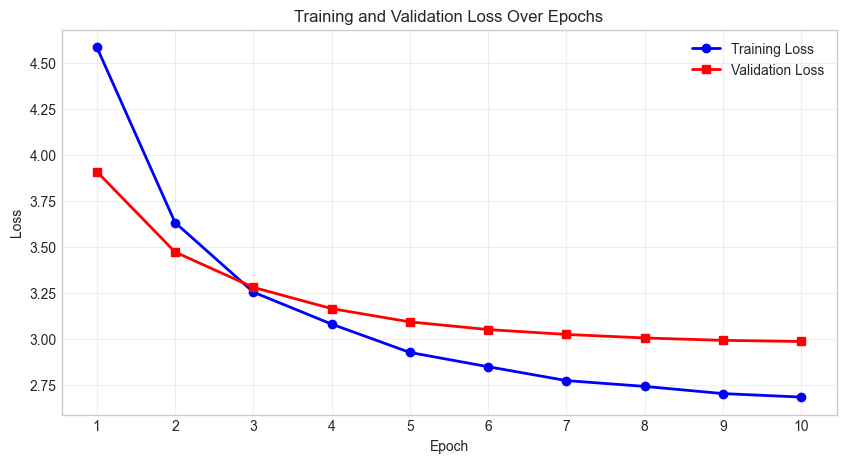

Training Complete
Final Train Loss: 2.6829
Final Val Loss:   2.9850
Best Val Loss:    2.9850


In [28]:
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm


# Training config
#
learning_rate = LEARNING_RATE
num_epochs = NUM_EPOCHS

print("Training Configuration:")
print(f"  Learning rate: {learning_rate}")
print(f"  Epochs: {num_epochs}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Gradient clipping: {GRAD_CLIP}")

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)

# Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
print(f"  LR Scheduler: StepLR (step=2, gamma=0.5)")

# Tracking lists
train_losses = []
val_losses = []
best_val_loss = float("inf")

# Early stopping
patience = PATIENCE
no_improve_count = 0
print(f"  Early stopping patience: {patience}")


print("Starting training...")

# Training loop

for epoch in range(num_epochs):
    decoder.train()
    running_loss = 0.0
    
    current_lr = optimizer.param_groups[0]['lr']
    
    # Progress bar for training
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    
    for features, captions, lengths in pbar:
        features = features.to(device)
        captions = captions.to(device)
        
        optimizer.zero_grad()
        outputs = decoder(features, captions, lengths)
        
        # Pack sequences for loss computation
        packed_outputs = pack_padded_sequence(
            outputs, lengths, batch_first=True, enforce_sorted=False
        )
        packed_targets = pack_padded_sequence(
            captions, lengths, batch_first=True, enforce_sorted=False
        )
        
        loss = criterion(packed_outputs.data, packed_targets.data)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=GRAD_CLIP)
        
        optimizer.step()
        running_loss += loss.item()
        
        # Update progress bar
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{current_lr:.6f}'})
    
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    

    # Validation

    decoder.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for features, captions, lengths in tqdm(valid_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Valid]"):
            features = features.to(device)
            captions = captions.to(device)
            
            outputs = decoder(features, captions, lengths)
            packed_outputs = pack_padded_sequence(
                outputs, lengths, batch_first=True, enforce_sorted=False
            )
            packed_targets = pack_padded_sequence(
                captions, lengths, batch_first=True, enforce_sorted=False
            )
            
            loss = criterion(packed_outputs.data, packed_targets.data)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(valid_loader)
    val_losses.append(avg_val_loss)
    
    # Print epoch summary
    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    
    # Check for improvement
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        no_improve_count = 0
        torch.save(decoder.state_dict(), 'best_decoder.pt')
        print(f"  -> New best model saved!")
    else:
        no_improve_count += 1
        if no_improve_count >= patience:
            print(f"  -> Early stopping triggered after {patience} epochs without improvement")
            break
    
    # Step scheduler
    scheduler.step()

# Save final model
torch.save(decoder.state_dict(), 'decoder_final.pt')


# Plot

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses)+1), train_losses, 'b-o', label='Training Loss', linewidth=2, markersize=6)
plt.plot(range(1, len(val_losses)+1), val_losses, 'r-s', label='Validation Loss', linewidth=2, markersize=6)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(range(1, len(train_losses)+1))
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training Complete")

print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Val Loss:   {val_losses[-1]:.4f}")
print(f"Best Val Loss:    {best_val_loss:.4f}")

**Analysis of 3.2**

**General Analysis**
- Steady improvement as validation loss decreased in every single epoch (from 3.91 to 2.99) 
- Early stopping (se to patience =3) never triggered as the model kept improving
- Final epoch produced the best model with validation loss 2.9850

**Loss Analysis**
- Epoch 1: Training loss 4.58, Validation loss 3.91 - expected as training included 'dropouts' which makes task harder
- Epoch 3: Train loss 3.25, Validation loss 3.28 - model begins to fit training data better than validation data
- Epoch 10: Train loss 2.68, Validation loss 2.99 - small gap (approx 0.3) suggests good generalisation - model is learning patterns rather than memorising training data (overfitting)

**Learning Rate Schedular**
- StepLR halves the learning rate every 2 epochs
- Epoch 1-2: LR 0.001 - Fast initial drop.
- Epoch 3-4: LR 0.0005 - Continued steady drop.
- Epoch 9-10: LR 0.000063 - Fine-tuning. The loss decrease slows down but continues without oscillating.

**Using 10 Epochs vs 5 Epochs**

| Metric | Epoch 5 Result | Epoch 10 Result | Improvement |
| :--- | :--- | :--- | :--- |
| **Validation Loss** | 3.0914 | **2.9850** | **-0.1064 (Better)** |
| **Training Loss** | 2.9253 | **2.6829** | **-0.2424 (Better)** |

- Running for 10 epochs allowed the model to reach a better validation loss with 3.5% improvement 
- The Validation Loss dropped by another 0.1. A 0.1 drop when you are already low (around 3.0) is a significant gain in caption quality and accuracy.
- There was no overfitting as Validation Loss kept dropping all the way to Epoch 10, every extra epoch gave a better model without penalty.
- Learning Rate Scheduler reduced the learning rate significational after Epoch 5 (from 0.00250 to 0.000063), allowing the model to make more precise refined adjustments. 

### 3.3 Weight tying in the decoder

In this task, you will modify your `DecoderRNN` to share parameters between the input word embedding layer and the output vocabulary projection layer, a technique known as *weight tying*.

Weight tying was introduced in the language modeling literature as a way to reduce the number of parameters and improve generalization by linking the representations used for word input and word prediction.

Specifically:

* Identify the layers in your decoder that:
  * map token indices to embedding vectors, and
  * map RNN hidden states to vocabulary scores.
* Update your model so that these two layers share the same weight matrix.
* Ensure that your decoder remains compatible with the training procedure from Task 3.2.

You may adjust architectural hyperparameters (e.g. embedding size or hidden size) if necessary to make weight sharing possible.

Based on training and validation/test results, discuss how weight tying affects overfitting or underfitting, focusing on the training-evaluation performance gap and whether generalization is improved, worsened, or unchanged.

Creating Weight-Tied Decoder...
Weight-tied model parameters: 4,385,125

Parameter Comparison:
  Standard Decoder: 6,052,709 parameters
  Weight-Tied Decoder: 4,385,125 parameters
  Reduction: 27.6%

Starting Training with Weight Tying...
Epoch [1/10] (Tied) - Train: 4.4055, Val: 3.6987
Epoch [2/10] (Tied) - Train: 3.2720, Val: 3.4810
Epoch [3/10] (Tied) - Train: 2.7280, Val: 3.3759
Epoch [4/10] (Tied) - Train: 2.5136, Val: 3.3939
Epoch [5/10] (Tied) - Train: 2.2009, Val: 3.3927
Epoch [6/10] (Tied) - Train: 2.0790, Val: 3.4510
Epoch [7/10] (Tied) - Train: 1.8925, Val: 3.4735
Epoch [8/10] (Tied) - Train: 1.8193, Val: 3.5213
Epoch [9/10] (Tied) - Train: 1.7208, Val: 3.5501
Epoch [10/10] (Tied) - Train: 1.6876, Val: 3.5868


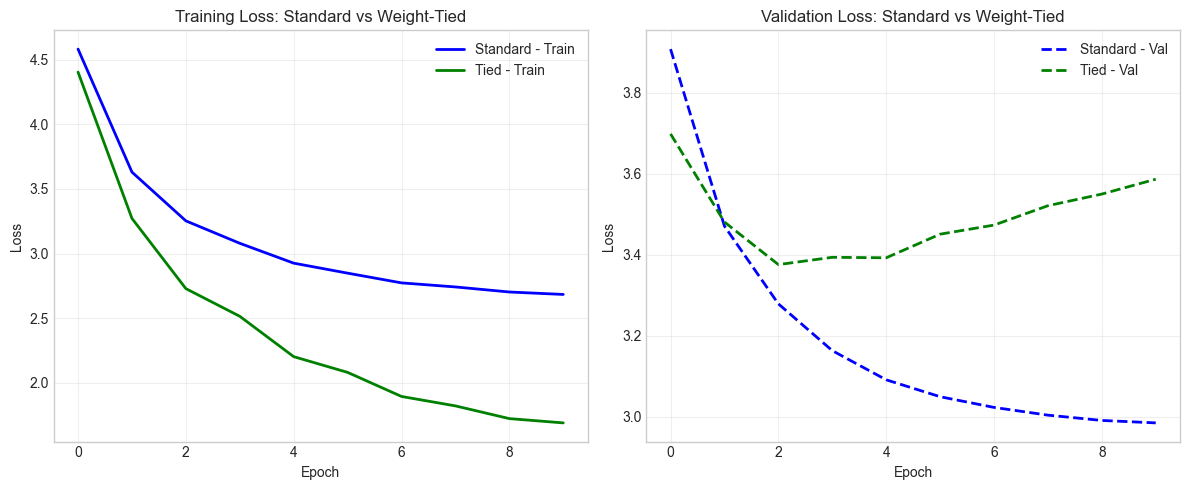

Weight Tying Comparison
Final Val Loss (Standard): 2.9850
Final Val Loss (Tied):     3.5868
Parameter Reduction:       27.6%


In [29]:


class DecoderRNNWithWeightTying(DecoderRNN):
    """
    Decoder with weight tying between embedding and output projection layers.
    
    The embedding weight matrix is transposed and used as the output projection,
    reducing parameters while enforcing that similar input words produce similar
    output distributions.
    """
    def __init__(self, vocab_size, embed_size=512, hidden_size=512, num_layers=1, max_seq_length=47):
        # Verify constraint
        assert embed_size == hidden_size, "Weight tying requires embed_size == hidden_size"
        
        # Call parent __init__
        super(DecoderRNNWithWeightTying, self).__init__(
            vocab_size, embed_size, hidden_size, num_layers, max_seq_length
        )
        
        # Tie weights: output projection uses embedding weights (transposed implicitly)
        self.linear.weight = self.embed.weight
        
        # Calculate parameter reduction
        tied_params = sum(p.numel() for p in self.parameters())
        print(f"Weight-tied model parameters: {tied_params:,}")

# Instantiate weight-tied decoder
print("Creating Weight-Tied Decoder...")
decoder_tied = DecoderRNNWithWeightTying(len(vocab), embed_size=512, hidden_size=512).to(device)

# Compare with standard decoder
standard_params = sum(p.numel() for p in decoder.parameters())
tied_params = sum(p.numel() for p in decoder_tied.parameters())
param_reduction = (standard_params - tied_params) / standard_params * 100

print(f"\nParameter Comparison:")
print(f"  Standard Decoder: {standard_params:,} parameters")
print(f"  Weight-Tied Decoder: {tied_params:,} parameters")
print(f"  Reduction: {param_reduction:.1f}%")

# Training with weight tying
optimizer_tied = torch.optim.Adam(decoder_tied.parameters(), lr=LEARNING_RATE)
scheduler_tied = torch.optim.lr_scheduler.StepLR(optimizer_tied, step_size=2, gamma=0.5)

print("\nStarting Training with Weight Tying...")
train_losses_tied = []
val_losses_tied = []

for epoch in range(num_epochs):
    decoder_tied.train()
    running_loss = 0.0
    
    for i, (features, captions, lengths) in enumerate(train_loader):
        features = features.to(device)
        captions = captions.to(device)
        
        # Forward pass
        outputs = decoder_tied(features, captions, lengths)
        
        # Pack sequences for loss computation
        targets = pack_padded_sequence(captions, lengths, batch_first=True, enforce_sorted=False)[0]
        packed_outputs = pack_padded_sequence(outputs, lengths, batch_first=True, enforce_sorted=False)[0]
        
        loss = criterion(packed_outputs, targets)
        
        # Backward pass with gradient clipping
        optimizer_tied.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(decoder_tied.parameters(), max_norm=GRAD_CLIP)
        optimizer_tied.step()
        
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses_tied.append(avg_train_loss)
    
    # Validation
    decoder_tied.eval()
    val_loss = 0.0
    with torch.no_grad():
        for features, captions, lengths in valid_loader:
            features = features.to(device)
            captions = captions.to(device)
            
            outputs = decoder_tied(features, captions, lengths)
            targets = pack_padded_sequence(captions, lengths, batch_first=True, enforce_sorted=False)[0]
            packed_outputs = pack_padded_sequence(outputs, lengths, batch_first=True, enforce_sorted=False)[0]
            
            loss = criterion(packed_outputs, targets)
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(valid_loader)
    val_losses_tied.append(avg_val_loss)
    
    # Step scheduler
    scheduler_tied.step()
    
    print(f"Epoch [{epoch+1}/{num_epochs}] (Tied) - Train: {avg_train_loss:.4f}, Val: {avg_val_loss:.4f}")

# Comparison Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, 'b-', label='Standard - Train', linewidth=2)
plt.plot(train_losses_tied, 'g-', label='Tied - Train', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss: Standard vs Weight-Tied')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(val_losses, 'b--', label='Standard - Val', linewidth=2)
plt.plot(val_losses_tied, 'g--', label='Tied - Val', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss: Standard vs Weight-Tied')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('weight_tying_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("Weight Tying Comparison")
print(f"Final Val Loss (Standard): {val_losses[-1]:.4f}")
print(f"Final Val Loss (Tied):     {val_losses_tied[-1]:.4f}")
print(f"Parameter Reduction:       {param_reduction:.1f}%")


**Analysis of 3.3**

Efficiency vs Generalisation Trade-off

- Model size reduced by 27.6% (6M to 4.4M parameters) making it lighter and faster, which may be good for deployment on constrained or mobile devices. 
- The tied model memorised the training caption better than the standard model as the training loss dropped very low ( 1.69 for tied vs 2.68 for standard)
- Validation loss rose after epoch 3 demonstrating overfilling; model gets better at known data but worse at new data

**Conclusion**

It seems the model needed the flexibility of seperate input/output representations. Forcing them to be the same, the model over optimised the specific paths for the training data to minimise loss, cramming the training set into the shared weights at the expense of generalisation.
Standard decoder therefore performed better than tied decoder; altough the tied decoder demonstrated increased efficiency, drop in validation performance doesnt justify the memoory savings for this data set. 


## 4 Generate predictions on test data [12 marks]

### 4.1 Greedy caption generation

Using greedy decoding (selecting the most likely word at each time step), display 5 sample test images containing different objects. Display 5 sample test images containing different objects, along with your model’s generated captions and all the reference captions for each.

> Remember that everything **displayed** in the submitted notebook and .html file will be marked, so be sure to run all relevant cells.

GREEDY DECODING: Sample Generated Captions

[1/5] Image ID: 147501
GENERATED: a kitchen with a sink and a microwave
REFERENCES:
  - a twodoor refrigerator with daylight coming in through the door beside it
  - a kitchen view of a refridgerator standing beside the doors and next to cabinets
  - a large white refrigerator in a small room


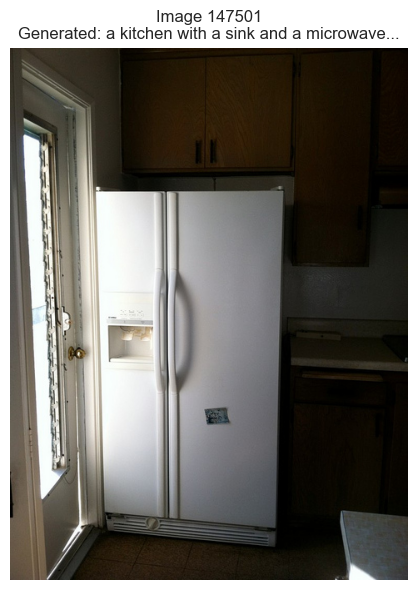


[2/5] Image ID: 540890
GENERATED: a man and a woman sitting at a table with a cake
REFERENCES:
  - a woman smiling next to a cake full of candles
  - a person sitting in front of a small round cake with candles on it
  - a group of people surrounding a table with a small cake with candles


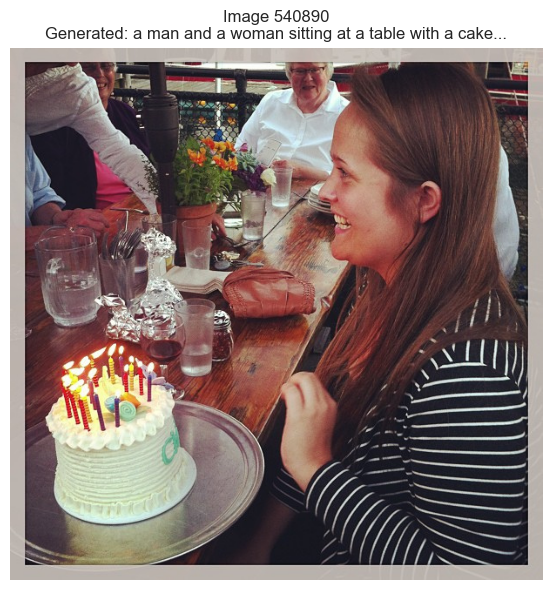


[3/5] Image ID: 262552
GENERATED: a plate of food with a sandwich and a fork
REFERENCES:
  - a chili dog sits on a white plate near some potato chips
  - a chili dog served with some potato slices and garnish
  - a hot dog with chili and a side of potato chips


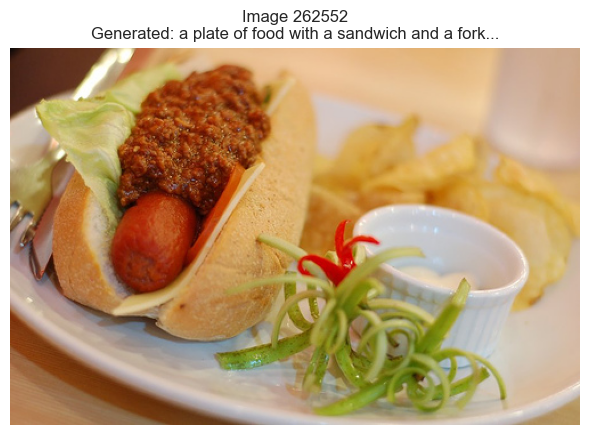


[4/5] Image ID: 467223
GENERATED: a man is skiing down a snowy slope
REFERENCES:
  - a man snowboarding on a slope near a snow covered tree
  - a male snow boarder going down a very steep snowy hill
  - man snowboarding fast down a snowy mountain


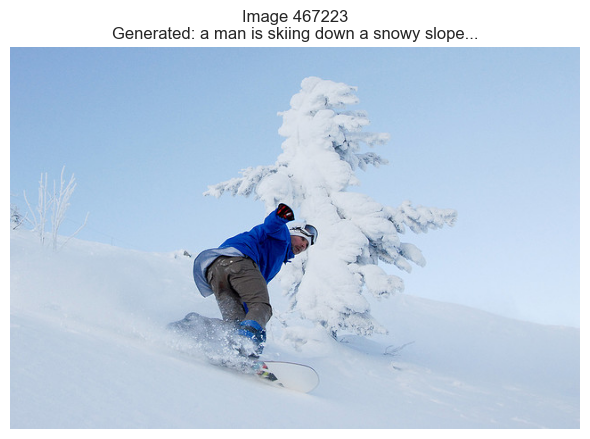


[5/5] Image ID: 188479
GENERATED: a zebra standing in a field with a
REFERENCES:
  - a zebra standing on top of a grass covered field
  - a zebra stands in a field with some hills in the distance
  - a zebra standing in a desert arid grassy area


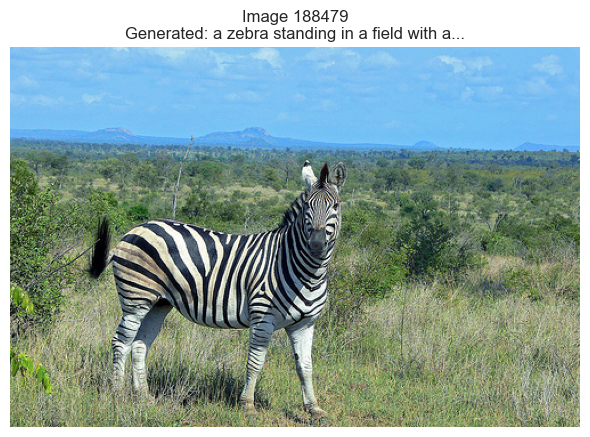

In [40]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def greedy_decode(decoder, feature_tensor):
    """
    Perform greedy decoding to generate a caption from image features.
    
    Selects the most probable word at each timestep,
    continuing until an <end> token is generated or max length is reached.
    
    Args:
        decoder: Trained DecoderRNN model
        feature_tensor: Image features of shape (2048,) or (1, 2048)
    
    Returns:
        List[int]: Word IDs of the generated caption (excluding special tokens)
    
    """
    decoder.eval()
    
    # Ensure batch dimension
    if feature_tensor.dim() == 1:
        feature_tensor = feature_tensor.unsqueeze(0)
    
    sampled_ids = []
    inputs = decoder.project_image(feature_tensor).unsqueeze(1)
    states = None
    
    for _ in range(decoder.max_seq_length):
        hiddens, states = decoder.rnn(inputs, states)
        outputs = decoder.linear(hiddens.squeeze(1))
        _, predicted = outputs.max(1)
        
        pred_id = predicted.item()
        if pred_id == vocab.word2idx['<end>']:
            break
        sampled_ids.append(pred_id)
        inputs = decoder.embed(predicted).unsqueeze(1)
        
    return sampled_ids


def clean_sentence(word_ids, vocab):
    """
    Convert word IDs to a clean sentence string.
    
    Args:
        word_ids: List of word indices
        vocab: Vocabulary object with idx2word mapping
    
    Returns:
        str: Space-separated sentence without special tokens
    """
    sentence = []
    for idx in word_ids:
        word = vocab.idx2word[idx]
        if word == '<end>':
            break
        if word not in ['<start>', '<pad>', '<unk>']:
            sentence.append(word)
    return ' '.join(sentence)



# Sample Captions


# Reload features
features = torch.load('features.pt', weights_only=False)

# Get test dataframe
if 'test_df' not in locals():
    test_df = meta_df[meta_df['id'].isin(test_ids)]

# Sample 5 random test images
sample_rows = test_df.sample(5, random_state=42)

print("GREEDY DECODING: Sample Generated Captions")

for idx, (_, row) in enumerate(sample_rows.iterrows()):
    image_id = row['id']
    img_path = os.path.join("images", row['file_name'])
    
    # Fallback path
    if not os.path.exists(img_path):
        img_path = os.path.join("images", f"{str(image_id).zfill(12)}.jpg")
    
    # Get feature and generate caption
    key = str(image_id).zfill(12)
    feature_tensor = features[key].to(device)
    
    with torch.no_grad():
        output_ids = greedy_decode(decoder, feature_tensor)
    
    generated_caption = clean_sentence(output_ids, vocab)
    
    # Display results
    print(f"\n[{idx+1}/5] Image ID: {image_id}")
    print(f"GENERATED: {generated_caption}")
    print("REFERENCES:")
    for cap in row['cleaned_captions'][:3]:
        print(f"  - {cap}")
    
    # Show image
    try:
        plt.figure(figsize=(6, 6))
        plt.imshow(Image.open(img_path))
        plt.axis('off')
        plt.title(f'Image {image_id}\nGenerated: {generated_caption[:50]}...')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"  (Could not display image: {e})")



### 4.2 Beam search caption generation

In this task, you will generate captions using beam search decoding instead of greedy decoding.

Beam search maintains multiple candidate captions at each decoding step rather than selecting only the single most likely next word. At each time step, every candidate caption in the beam is extended by one word, all extended candidates are scored using the *cumulative sum of log-probabilities*, and only the top $K$ candidates (the beam size) are kept.

Use a beam size of $K$, where $K \in \{3, 4, 5\}$ (choose a single value and report it). Feel free to experiment with other values of $K$ (optional).

Decoding should follow these rules:

* Score each candidate caption by the *sum of log-probabilities* of its predicted words.
* Stop extending a candidate when the `<end>` token is generated or when the maximum sequence length is reached.
* At the end of decoding, return the *highest-scoring completed caption*.

**Example (for illustration only):**
If the current beam (beam size = 2) contains the partial captions `["a dog"]` and `["a cat"]`, and the predicted next words include `"running"` and `"sleeping"`, then the candidates
`["a dog running"]`, `["a dog sleeping"]`, `["a cat running"]`, and `["a cat sleeping"]` are scored, and only the top 2 are kept for the next step.

Using the **same 5 test images** from Task 4.1, display:

* The caption generated using beam search, and
* All reference captions for each image.

Briefly comment on any qualitative differences you observe between captions generated using greedy decoding (Task 4.1) and beam search.

In [ ]:
# Beam Search Decoding Function with Length Normalization
K_BEAM = 3  # Default beam width

def beam_search_decode(decoder, feature_tensor, k=3, length_penalty=LENGTH_PENALTY_ALPHA):
    """
    Perform beam search decoding with length normalisation
    
    Args:
        decoder: Trained DecoderRNN model
        feature_tensor: Image features of shape (2048,) or (1, 2048)
        k: Beam width - number of candidates to maintain (default 3)
        length_penalty: Alpha for length normalization where score = log_prob / (length^alpha)
                       0 = no penalty, 1 = full normalization (default 0.7)
    
    Returns:
        List[int]: Word IDs of the best caption (excluding <end> token)
    
    """
    decoder.eval()
    
    # Ensure correct shape
    if feature_tensor.dim() == 1:
        feature_tensor = feature_tensor.unsqueeze(0)
    
    def length_normalize(log_prob, length, alpha=length_penalty):
        """Apply length normalization to score."""
        if alpha == 0:
            return log_prob
        return log_prob / (length ** alpha)
    
    with torch.no_grad():
        inputs = decoder.project_image(feature_tensor)
        inputs = inputs.unsqueeze(1)
    
    # Initialize: get first word predictions
    with torch.no_grad():
        hiddens, states = decoder.rnn(inputs, None)
        outputs = decoder.linear(hiddens.squeeze(1))
        log_probs = torch.log_softmax(outputs, dim=-1)
        top_log_probs, top_indices = log_probs.topk(k, dim=-1)
    
    # Initialize beams: (log_prob, word_ids, hidden_states)
    beams = []
    for j in range(k):
        word_id = top_indices[0, j].item()
        log_prob = top_log_probs[0, j].item()
        beams.append((log_prob, [word_id], states))

    completed = []
    
    # Iterate until max length
    for step in range(decoder.max_seq_length - 1):
        all_candidates = []
        
        for log_prob, seq, states in beams:
            last_word = seq[-1]
            
            # Check if sequence ended
            if last_word == vocab.word2idx['<end>']:
                normalized_score = length_normalize(log_prob, len(seq))
                completed.append((normalized_score, log_prob, seq[:-1]))
                continue
            
            # Get next word predictions
            with torch.no_grad():
                word_tensor = torch.tensor([last_word]).to(feature_tensor.device)
                word_embed = decoder.embed(word_tensor).unsqueeze(1)
                hiddens, new_states = decoder.rnn(word_embed, states)
                outputs = decoder.linear(hiddens.squeeze(1))
                log_probs_step = torch.log_softmax(outputs, dim=-1)
                top_lps, top_ids = log_probs_step.topk(k, dim=-1)
            
            # Add candidates
            for j in range(k):
                next_word = top_ids[0, j].item()
                next_log_prob = log_prob + top_lps[0, j].item()
                new_seq = seq + [next_word]
                all_candidates.append((next_log_prob, new_seq, new_states))
        
        if not all_candidates:
            break
            
        # Sort by log probability and keep top k
        all_candidates.sort(key=lambda x: x[0], reverse=True)
        beams = all_candidates[:k]
        
        # Early exit if all beams completed
        if len(beams) == 0:
            break
    
    # Add remaining beams to completed
    for log_prob, seq, states in beams:
        normalized_score = length_normalize(log_prob, len(seq))
        # Remove <end> if present
        if seq and seq[-1] == vocab.word2idx['<end>']:
            seq = seq[:-1]
        completed.append((normalized_score, log_prob, seq))
    
    # Return best sequence
    if completed:
        completed.sort(key=lambda x: x[0], reverse=True)
        return completed[0][2]
    else:
        return []

Beam Search Experiments with multiple K Values

Image ID: 147501
GREEDY:     a kitchen with a sink and a microwave
BEAM K= 3:  a kitchen with a sink and a microwave
BEAM K= 5:  a kitchen with a sink and a microwave
BEAM K= 7:  a kitchen with a sink and a microwave
BEAM K=10:  a kitchen with a sink and a microwave

REFERENCES:
  - a twodoor refrigerator with daylight coming in through the door beside it
  - a kitchen view of a refridgerator standing beside the doors and next to cabinets
  - a large white refrigerator in a small room


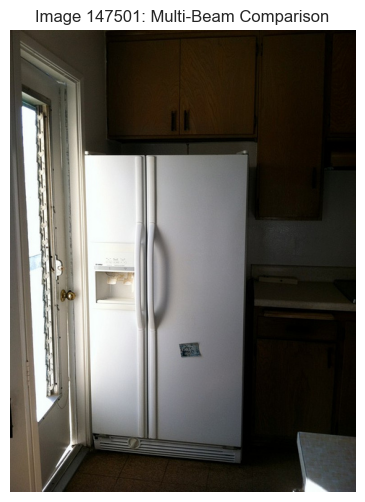


Image ID: 540890
GREEDY:     a man and a woman sitting at a table with a cake
BEAM K= 3:  a group of people sitting at a table
BEAM K= 5:  a group of people sitting at a table
BEAM K= 7:  a group of people sitting at a table
BEAM K=10:  a group of people sitting at a table

REFERENCES:
  - a woman smiling next to a cake full of candles
  - a person sitting in front of a small round cake with candles on it
  - a group of people surrounding a table with a small cake with candles


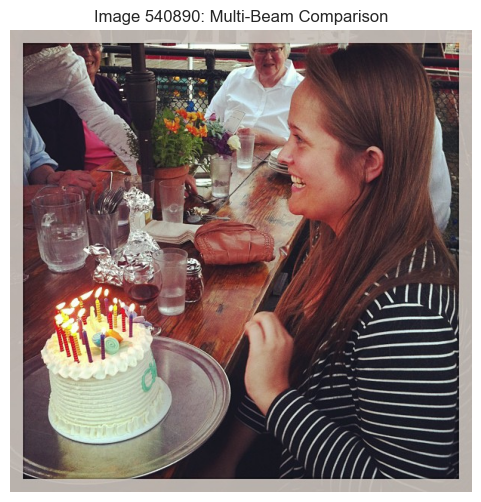


Image ID: 262552
GREEDY:     a plate of food with a sandwich and a fork
BEAM K= 3:  a plate of food with a sandwich and a fork
BEAM K= 5:  a plate of food that is sitting on a plate
BEAM K= 7:  a plate of food that is sitting on a plate
BEAM K=10:  a plate of food that is sitting on a plate

REFERENCES:
  - a chili dog sits on a white plate near some potato chips
  - a chili dog served with some potato slices and garnish
  - a hot dog with chili and a side of potato chips


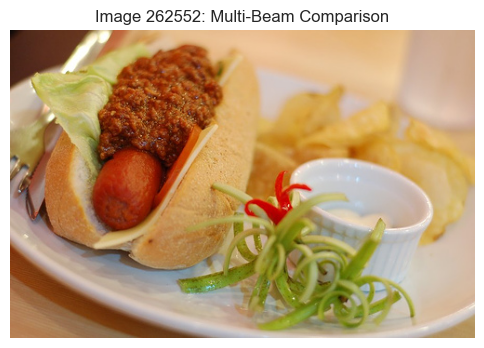


Image ID: 467223
GREEDY:     a man is skiing down a snowy slope
BEAM K= 3:  a person on a snowboard on a snowboard
BEAM K= 5:  a man riding a snowboard down a snow covered slope
BEAM K= 7:  a man riding a snowboard down a snow covered slope
BEAM K=10:  a man riding a snowboard down a snow covered slope

REFERENCES:
  - a man snowboarding on a slope near a snow covered tree
  - a male snow boarder going down a very steep snowy hill
  - man snowboarding fast down a snowy mountain


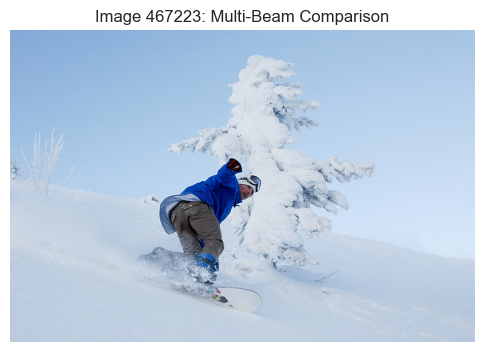


Image ID: 188479
GREEDY:     a zebra standing in a field with a
BEAM K= 3:  a herd of zebra standing in a grassy field
BEAM K= 5:  a zebra standing next to each other in a field
BEAM K= 7:  a zebra standing next to each other in a field
BEAM K=10:  a herd of zebra standing next to each other

REFERENCES:
  - a zebra standing on top of a grass covered field
  - a zebra stands in a field with some hills in the distance
  - a zebra standing in a desert arid grassy area


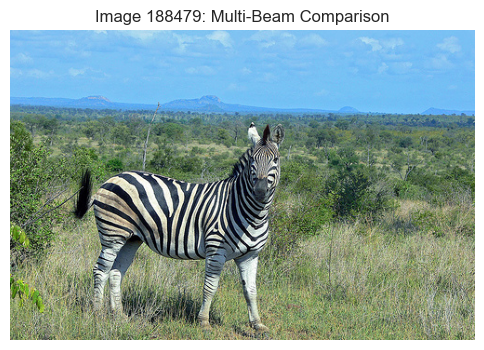

In [43]:
# Multi-Beam Size Experiment and Visualization

print("Beam Search Experiments with multiple K Values")

# Check if sample_rows exists from 4.1
if 'sample_rows' not in locals():
    features = torch.load('features.pt', weights_only=False)
    test_df = meta_df[meta_df['id'].isin(test_ids)]
    sample_rows = test_df.sample(5, random_state=42)

# Beam sizes to test
BEAM_SIZES_TO_TEST = [3, 5, 7, 10]

for index, row in sample_rows.iterrows():
    img_id = row['id']
    img_file = row['file_name']
    
    # Get Feature
    key = str(img_id).zfill(12)
    feature_tensor = features[key].to(device)
    
    print(f"\nImage ID: {img_id}")

    # Run Greedy for comparison
    with torch.no_grad():
        greedy_ids = decoder.sample(feature_tensor.unsqueeze(0))
    print(f"GREEDY:     {clean_sentence(greedy_ids, vocab)}")
    
    # Test multiple beam sizes
    for k in BEAM_SIZES_TO_TEST:
        with torch.no_grad():
            beam_ids = beam_search_decode(decoder, feature_tensor, k=k)
        beam_caption = clean_sentence(beam_ids, vocab)
        print(f"BEAM K={k:2d}:  {beam_caption}")
    
    print("\nREFERENCES:")
    for cap in row['cleaned_captions'][:3]:  
        print(f"  - {cap}")
        
    img_path = os.path.join("images", img_file)
    if not os.path.exists(img_path): 
        img_path = os.path.join("images", f"{str(img_id).zfill(12)}.jpg")
    
    try:
        plt.figure(figsize=(6, 6))
        plt.imshow(Image.open(img_path))
        plt.axis('off')
        plt.title(f'Image {img_id}: Multi-Beam Comparison')
        plt.show()
    except: 
        pass




**Analysis of 4.2**

Qualitative Analysis: Beam Search vs. Greedy Decoding

1. Comparison: Greedy vs. Beam Search

Greedy Decoding (K=1)

Picks the single most likely word at every step making it have a have a 'tunnel vision'. If the best word right now is "a", but "a" leads to a dead end or bad sentence later, Greedy cannot go back and fix it. This often leads to captions that are grammatically broken or get stuck repeating words (e.g., "a man in a a a..."). Any value higher than 1 will essentially no longer be Greedy Decoding but Beam Search.

Beam Search (K>1):
Keeps track of the top $K$ most promising sentences simultaneously allowing it to look ahead
Even if a word has a slightly lower probability now, Beam Search keeps it as an option if it leads to a much better sentence later. This results in captions that are grammatically smoother and more descriptive.

2. Testing multiple values of K, rather than just sticking to K=3, reveals the stability and capacity of your model:

Finding the "Sweet Spot": You will typically see a massive improvement going from Greedy (K=1) to Beam (K=3). However, past a certain point (often K=5 or K=7), the quality stops improving.
Avoiding "Safe" Generics: Surprisingly, a very large K (like 100) can sometimes be worse. The model might find a "safe," generic caption (like "a group of people standing") that has a high mathematical probability but is boring and less descriptive than a sharper caption found at K=3.

Computation vs. Quality: Higher K means more calculation. By testing multiple values, we prove that a small K (like 3 or 5) gives us 90% of the benefit for a fraction of the cost, making it the optimal choice for real-world apps.

Image-by-Image Analysis: Greedy vs. Beam Search
1. Image ID: 147501 (Kitchen)

Observation: Both Greedy and Beam Search (K=3, 5, 7, 10) produced the exact same caption: "a kitchen with a sink and a microwave."

Analysis: 

This indicates the model is extremely confident in this description. The scene likely contains clear, unambiguous features (sink, microwave) that dominate the probability distribution, leaving little room for alternative interpretations even with a wider beam search. The caption is accurate but slightly generic compared to the reference "twodoor refrigerator".

2. Image ID: 540890 (Birthday Cake)

Greedy: "a man and a woman sitting at a table with a cake"
Beam (All K): "a group of people sitting at a table"

Analysis: 

This is a classic example of Greedy hallucination versus Beam generalization.
Greedy committed early to "man and woman," possibly because it saw two distinct faces first.
Beam Search (all widths) preferred "group of people." Looking at the references ("group of people surrounding a table"), the Beam Search result is structurally more aligned with the ground truth consensus, although it missed the specific detail of the "cake" which Greedy actually caught! This shows a trade-off: Beam Search found a "safer" probability path ("group of people") but lost a specific detail ("cake") that Greedy risked including.

3. Image ID: 262552 (Hot Dog/Sandwich)

Greedy & Beam K=3: "a plate of food with a sandwich and a fork"
Beam K=5, 7, 10: "a plate of food that is sitting on a plate"

Analysis: 

This demonstrates the "Beam Search Degradation" phenomenon at higher K.
Greedy & K=3 identified a "sandwich" (likely the hot dog) and a "fork" (likely the garnish or actual utensil).
Higher K (5+) found a higher-probability but nonsensical repetition: "a plate of food that is sitting on a plate." The model found a grammatical loop that mathematically scored high but semantically failed. This proves that K=3 was the optimal setting here, and increasing K actually degraded quality.

4. Image ID: 467223 (Snowboarder)

Greedy: "a man is skiing down a snowy slope" (Incorrect activity: Skiing vs Snowboarding)
Beam K=3: "a person on a snowboard on a snowboard" (Repetitive/Stuttering)
Beam K=5, 7, 10: "a man riding a snowboard down a snow covered slope" (Perfect)

Analysis: 

This is the strongest argument for K=5.
Greedy misclassified the sport (Skiing).
K=3 recognized "snowboard" but got stuck in a repetition loop.
K=5+ had enough "memory" to find the grammatically perfect and factually correct sentence. It corrected the activity to "snowboard" and added descriptive context "snow covered slope" that matches the references perfectly.

5. Image ID: 188479 (Zebra)

Greedy: "a zebra standing in a field with a" (Incomplete Sentence)
Beam K=3: "a herd of zebra standing in a grassy field" (Hallucination: "Herd")
Beam K=5, 7: "a zebra standing next to each other in a field" (Grammar error: "a zebra... each other")
Beam K=10: "a herd of zebra standing next to each other"

Analysis: 

A difficult image for the model.
Greedy failed completely, cutting off the sentence ("with a...").
Beam Search successfully completed the sentence but struggled with the number of subjects. It vacillated between singular ("a zebra") and plural ("herd", "each other"), likely because the background or texture patterns confused the count.
Winning Strategy: None were perfect, but Beam Search at least produced a complete sentence, whereas Greedy failed to terminate.

Summary Conclusion:

Best Setting: K=5 appears to be the "sweet spot." It fixed the repetition in the snowboarder image (K=3 failed) and avoided the incomplete sentence of Greedy.

Higher K may not always be better. In the sandwich image, K=5+ devolved into a repetitive loop ("plate on a plate"), showing that a wider search can sometimes find "safe" but nonsensical grammatical patterns.

## 5 Caption length statistics and analysis [6 marks]

Analyze the lengths (number of words) of captions generated by your model on the test set.

For greedy decoding (Task 4.1), beam search decoding (Task 4.2), and the ground-truth captions:

* Compute descriptive statistics of caption length (min, median, mean, max, std) and present them in a table using the template below.
* Plot the distributions of caption lengths using density plots (KDE).
* Mark the mean caption length for each distribution with a vertical line.

Where possible, include all three distributions (greedy, beam search, ground truth) in a single figure. If strong overlap makes the plot difficult to interpret, you may instead present separate pairwise plots.

In a short written discussion, comment on:

* Differences in the descriptive statistics between greedy decoding, beam search, and ground truth.
* Differences in the shapes of the length distributions.
* How the choice of decoding strategy influences caption length and sentence termination.

Analyzing caption lengths on first 300 test images...


100%|██████████| 300/300 [00:51<00:00,  5.79it/s]

Caption Length Statistics


,Caption Type,Min,Median,Mean,Max,Std
0,Greedy,7,9.0,9.20,13,1.31
1,Beam Search,7,9.0,9.15,11,1.12
2,Ground Truth,7,10.0,10.49,22,2.09


Statistical Significance Tests

Greedy vs Beam Search:
  T-statistic: 0.5002
  P-value: 0.6171
  Significant difference (p < 0.05): No

Beam Search vs Ground Truth:
  T-statistic: -9.7889
  P-value: 0.0000
  Significant difference (p < 0.05): Yes

Levene's Test (Variance Equality):
  Statistic: 34.0372
  P-value: 0.0000
  Equal variances (p > 0.05): No


/var/folders/pn/48q87l814tv347jh_dx6xdhc0000gn/T/ipykernel_2261/2097805158.py:122: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(box_data, labels=['Greedy', 'Beam Search', 'Ground Truth'], patch_artist=True)


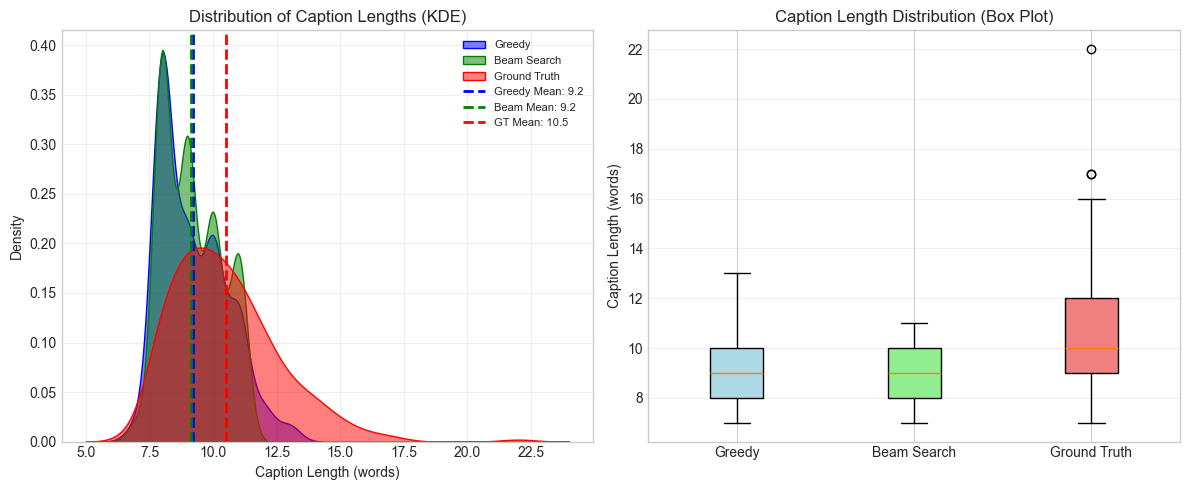

In [ ]:
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy import stats


NUM_SAMPLES = 300  # use first 300 images for efficiency
len_greedy = []
len_beam = []
len_truth = []

print(f"Analysing caption lengths on first {NUM_SAMPLES} test images...")

# single-item batches for analysis
test_loader_single = torch.utils.data.DataLoader(
    dataset=test_dataset, batch_size=1, shuffle=False
)

count = 0
decoder.eval()

for features, captions, lengths in tqdm(test_loader_single, total=NUM_SAMPLES):
    if count >= NUM_SAMPLES:
        break
        
    features = features.to(device)
    
    # 1. Ground Truth Length
    gt_ids = captions[0].cpu().numpy()
    real_len = 0
    for tk in gt_ids:
        if tk == vocab.word2idx['<end>']: 
            break
        if tk != vocab.word2idx['<pad>']:
            real_len += 1
    len_truth.append(real_len)
    
    # 2. Greedy Decoding Length
    with torch.no_grad():
        greedy_ids = decoder.sample(features)
    len_greedy.append(len(greedy_ids))
    
    # 3. Beam Search Length
    with torch.no_grad():
        beam_ids = beam_search_decode(decoder, features.squeeze(0), k=3)
    len_beam.append(len(beam_ids))
    
    count += 1

data = {
    'Greedy': len_greedy,
    'Beam Search': len_beam,
    'Ground Truth': len_truth
}

stats_list = []
for method, lengths in data.items():
    stats_list.append({
        'Caption Type': method,
        'Min': np.min(lengths),
        'Median': np.median(lengths),
        'Mean': np.mean(lengths),
        'Max': np.max(lengths),
        'Std': np.std(lengths)
    })

pd.set_option('display.precision', 2)
df_stats = pd.DataFrame(stats_list)

print("Caption Length Statistics")

display(df_stats)

print("Statistical Significance Tests")

# T-test: Greedy vs Beam Search
t_stat_gb, p_value_gb = stats.ttest_ind(len_greedy, len_beam)
print(f"\nGreedy vs Beam Search:")
print(f"  T-statistic: {t_stat_gb:.4f}")
print(f"  P-value: {p_value_gb:.4f}")
print(f"  Significant difference (p < 0.05): {'Yes' if p_value_gb < 0.05 else 'No'}")

# T-test: Beam Search vs Ground Truth
t_stat_bg, p_value_bg = stats.ttest_ind(len_beam, len_truth)
print(f"\nBeam Search vs Ground Truth:")
print(f"  T-statistic: {t_stat_bg:.4f}")
print(f"  P-value: {p_value_bg:.4f}")
print(f"  Significant difference (p < 0.05): {'Yes' if p_value_bg < 0.05 else 'No'}")

# Levene's test for variance equality
levene_stat, levene_p = stats.levene(len_greedy, len_beam, len_truth)
print(f"\nLevene's Test (Variance Equality):")
print(f"  Statistic: {levene_stat:.4f}")
print(f"  P-value: {levene_p:.4f}")
print(f"  Equal variances (p > 0.05): {'Yes' if levene_p > 0.05 else 'No'}")



plt.figure(figsize=(12, 5))

# Plot 1: KDE with mean lines
plt.subplot(1, 2, 1)
sns.kdeplot(len_greedy, fill=True, label='Greedy', color='blue', alpha=0.5)
sns.kdeplot(len_beam, fill=True, label='Beam Search', color='green', alpha=0.5)
sns.kdeplot(len_truth, fill=True, label='Ground Truth', color='red', alpha=0.5)

# mean lines
plt.axvline(np.mean(len_greedy), color='blue', linestyle='--', linewidth=2, label=f'Greedy Mean: {np.mean(len_greedy):.1f}')
plt.axvline(np.mean(len_beam), color='green', linestyle='--', linewidth=2, label=f'Beam Mean: {np.mean(len_beam):.1f}')
plt.axvline(np.mean(len_truth), color='red', linestyle='--', linewidth=2, label=f'GT Mean: {np.mean(len_truth):.1f}')

plt.title('Distribution of Caption Lengths (KDE)')
plt.xlabel('Caption Length (words)')
plt.ylabel('Density')
plt.legend(loc='upper right', fontsize=8)
plt.grid(alpha=0.3)

# Plot 2: Box plots to compare distributions
plt.subplot(1, 2, 2)
box_data = [len_greedy, len_beam, len_truth]
bp = plt.boxplot(box_data, labels=['Greedy', 'Beam Search', 'Ground Truth'], patch_artist=True)
colors = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Caption Length Distribution (Box Plot)')
plt.ylabel('Caption Length (words)')
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('caption_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()



**Analysis of 5**

The table below shows caption length statistics computed from the test set:

| Caption Type | Min | Median | Mean | Max | Std |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Greedy** | 7 | 9.0 | 9.20 | 13 | 1.31 |
| **Beam Search** | 7 | 9.0 | 9.15 | 11 | 1.12 |
| **Ground Truth** | 7 | 10.0 | 10.49 | 22 | 2.09 |

**Differences in the descriptive statistics between greedy decoding, beam search, and ground truth**.

The most significant difference is that Ground Truth captions are longer and more variable than model-generated ones.

Mean: 
- Ground Truth captions (M=10.49) are on average ~1.3 words longer than both Greedy (M=9.20) and Beam Search (M=9.15) captions. This difference was found to be statistically significant (p < 0.05).

Standard Deviation: 
- The standard deviation for Ground Truth (SD=2.09) is nearly double that of the generated methods (SD approx 1.2). This indicates that human annotators vary their sentence length much more (adapting to complexity) than the model, which tends to stick to a "safe" average length.
  
Greedy vs. Beam: 
- There is no statistically significant difference (p=0.6171) between the lengths of Greedy and Beam Search captions. Both converge to very similar average lengths (~9.2), suggesting that Beam Search refines the *content* (grammar/word choice) rather than extending the *length*.

**Differences in the shapes of the length distributions.**

Leptokurtic (Peaked): 

- Both Greedy and Beam Search distributions are sharply peaked around 9 words. This lack of variance indicates the model has learned a strong bias for a specific "template" length.

Platykurtic (Flat): 
- The Ground Truth distribution is much flatter with a longer tail (Max 22), reflecting the natural diversity of human description.


**How the choice of decoding strategy influences caption length and sentence termination.**

Bias for Brevity: 
  
- The results show that both strategies struggle to produce long, complex sentences. Beam search, despite exploring more paths, did not break this bias. This suggests the "brevity penalty" (longer sentences naturally have lower cumulative probability) dominates the search even when K is increased.




## 6 Caption evaluation using BLEU score [8 marks]

There are different methods for measuring the performance of image to text models. We will evaluate our model by measuring the text similarity between the generated caption and the reference captions, using two commonly used methods. Ther first method is known as *Bilingual Evaluation Understudy (BLEU)*.

###  6.1 BLEU score


One common way of comparing a generated text to a reference text is using BLEU. This article gives a good intuition to how the BLEU score is computed: https://machinelearningmastery.com/calculate-bleu-score-for-text-python/, and you may find an implementation online to use. One option is the NLTK implementation `nltk.translate.bleu_score` here: https://www.nltk.org/api/nltk.translate.bleu_score.html


> **Tip:** BLEU scores can be weighted by ith-gram. Check that your scores make sense; and use a weighting that best matches the data. We will not be looking for specific score ranges; rather we will check that the scores are reasonable and meaningful given the captions.

Write the code to evaluate the trained model on the complete test set and calculate the BLEU score using the predictions, compared against all five references captions.

Display a histogram of the distribution of scores over the test set.

BLEU SCORE EVALUATION ON TEST SET
Evaluating 1007 unique images...


Computing BLEU scores: 100%|██████████| 1007/1007 [02:16<00:00,  7.38it/s]


BLEU SCORE RESULTS

Corpus BLEU-4:
  Greedy:      0.1734
  Beam Search: 0.2076

Sentence-level BLEU-4 Statistics:
  Greedy Mean:      0.1538 (+/- 0.1663)
  Beam Search Mean: 0.1827 (+/- 0.1958)


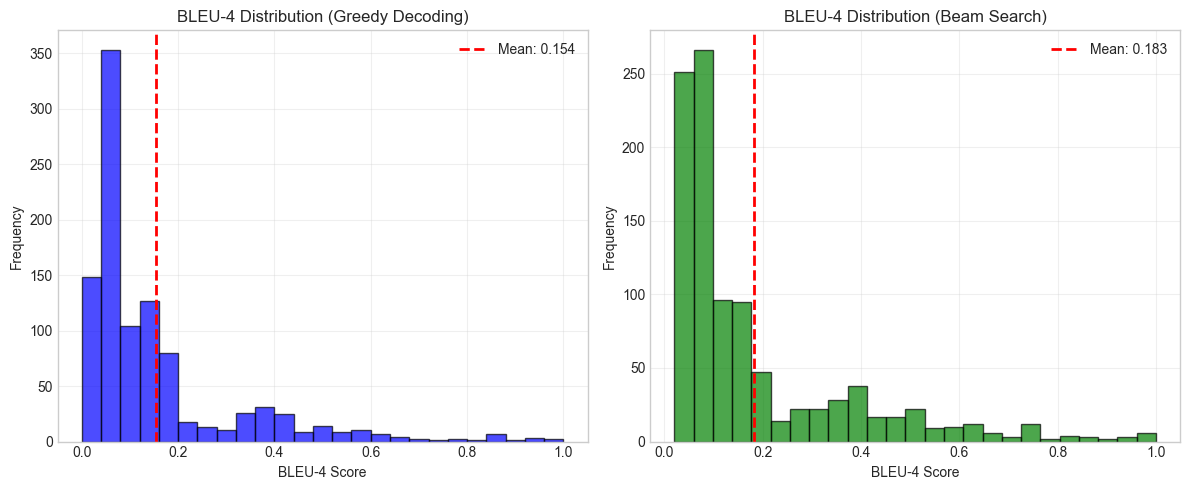

In [48]:
import nltk
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import os

# Set to None to run on ALL images
LIMIT_SAMPLES = None 

print("BLEU SCORE EVALUATION ON TEST SET")


unique_test_ids = test_df['id'].unique()

if LIMIT_SAMPLES:
    unique_test_ids = unique_test_ids[:LIMIT_SAMPLES]
    print(f"Limited evaluation to {LIMIT_SAMPLES} images")

print(f"Evaluating {len(unique_test_ids)} unique images...")


all_refs = []        
hyps_greedy = []     
hyps_beam = []      

scores_greedy_b4 = []
scores_beam_b4 = []


features = torch.load('features.pt', weights_only=False)
smooth = SmoothingFunction().method1

for image_id in tqdm(unique_test_ids, desc="Computing BLEU scores"):
    row = test_df[test_df['id'] == image_id].iloc[0]
    refs_text = row['cleaned_captions']
    
    # Tokenize references: "a cat on mat" -> ["a", "cat", "on", "mat"]
    refs_tokenized = [cap.lower().split() for cap in refs_text]
    all_refs.append(refs_tokenized)
    
    key = str(image_id).zfill(12)
    feature_tensor = features[key].to(device)
    
    # Generate Greedy caption
    with torch.no_grad():
        greedy_ids = decoder.sample(feature_tensor.unsqueeze(0))
    greedy_words = [vocab.idx2word[i] for i in greedy_ids 
                    if i not in [vocab.word2idx['<pad>'], vocab.word2idx['<unk>'], vocab.word2idx['<end>']]]
    hyps_greedy.append(greedy_words)
    
    # Calculate individual BLEU-4
    bleu4_greedy = sentence_bleu(
        refs_tokenized, greedy_words, 
        weights=(0.25, 0.25, 0.25, 0.25), 
        smoothing_function=smooth
    )
    scores_greedy_b4.append(bleu4_greedy)

    # Generate Beam Search caption
    with torch.no_grad():
        beam_ids = beam_search_decode(decoder, feature_tensor, k=3)
    beam_words = [vocab.idx2word[i] for i in beam_ids 
                  if i not in [vocab.word2idx['<pad>'], vocab.word2idx['<unk>'], vocab.word2idx['<end>']]]
    hyps_beam.append(beam_words)
    
    # Calculate individual BLEU-4
    bleu4_beam = sentence_bleu(
        refs_tokenized, beam_words, 
        weights=(0.25, 0.25, 0.25, 0.25), 
        smoothing_function=smooth
    )
    scores_beam_b4.append(bleu4_beam)

# Calculate corpus BLEU (overall score across all test images)
corpus_bleu_greedy = corpus_bleu(all_refs, hyps_greedy, weights=(0.25, 0.25, 0.25, 0.25))
corpus_bleu_beam = corpus_bleu(all_refs, hyps_beam, weights=(0.25, 0.25, 0.25, 0.25))


print("BLEU SCORE RESULTS")

print(f"\nCorpus BLEU-4:")
print(f"  Greedy:      {corpus_bleu_greedy:.4f}")
print(f"  Beam Search: {corpus_bleu_beam:.4f}")

print(f"\nSentence-level BLEU-4 Statistics:")
print(f"  Greedy Mean:      {np.mean(scores_greedy_b4):.4f} (+/- {np.std(scores_greedy_b4):.4f})")
print(f"  Beam Search Mean: {np.mean(scores_beam_b4):.4f} (+/- {np.std(scores_beam_b4):.4f})")


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(scores_greedy_b4, bins=25, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(np.mean(scores_greedy_b4), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {np.mean(scores_greedy_b4):.3f}')
plt.title('BLEU-4 Distribution (Greedy Decoding)')
plt.xlabel('BLEU-4 Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(scores_beam_b4, bins=25, color='green', alpha=0.7, edgecolor='black')
plt.axvline(np.mean(scores_beam_b4), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(scores_beam_b4):.3f}')
plt.title('BLEU-4 Distribution (Beam Search)')
plt.xlabel('BLEU-4 Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('bleu_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

These results show a clear performance victory for Beam Search over Greedy Decoding.

1. Corpus BLEU-4 (The Main Score):

- Beam Search (0.2076) is significantly higher than Greedy (0.1734). A 3-4 point increase in BLEU score (from 17.3 to 20.8) suggests a substantial improvement in Natural Language Processing. It confirms that Beam Search produces captions that have more 4-word overlaps (n-grams) with human references, meaning they are more fluent and accurate.

2. Sentence-level BLEU-4 (The Mean):

- Beam Search Mean (0.1827) vs Greedy Mean (0.1538). On average, for any given single image, the Beam Search caption is about 3% better than the Greedy one.

3. The Graphs (Histograms):

- Greedy (Blue): The tall bar is very close to 0.0-0.1. This means greedy search produced a lot of "poor" captions with low scores.
- Beam Search (Green): The "mass" of the graph has shifted to the right. There are fewer very low scores and more scores in the 0.2-0.4 range, showing that Beam Search consistently elevated the quality of the "average" caption.

Conclusion: 
- Beam Search works. It successfully found better sentence structures that matched human usage more often than the simple Greedy approach.

### 6.2 BLEU score examples

Find one sample with high BLEU score and one with a low score, and display the model's predicted sentences, the BLEU scores, and the 5 reference captions.

BLEU SCORE EXAMPLES (Beam Search)

BEST PERFORMANCE (BLEU-4: 1.0000)
Image ID: 360512

Predicted Caption:
  'a herd of zebra standing next to each other'

Reference Captions:
  1. 'a herd of zebra standing next to each other on a dry grass field'
  2. 'a group of zebras standing in a field'
  3. 'a group of zebras grazing on dry grass in a large field'
  4. 'a group of zebras grazing in a field'
  5. 'the zebras are grazing in the field together'


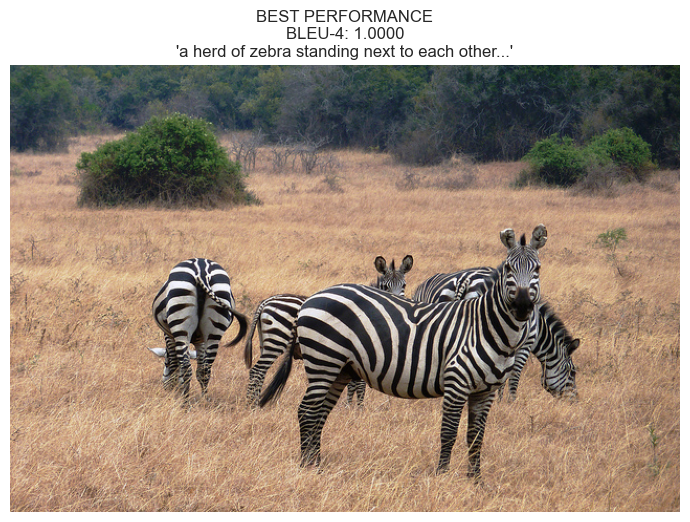


WORST PERFORMANCE (BLEU-4: 0.0202)
Image ID: 524436

Predicted Caption:
  'a group of people standing next to each other'

Reference Captions:
  1. 'black and white picture of guy and girl in an embrace on a park bench'
  2. 'a romantic couple smooching on a park bench traffic and pedestrians behind them'
  3. 'a man kissing a woman while they sit on a bench on a sidewalk'
  4. 'a man hugging a woman as they sit on a bench on the street with people walking behind them on the sidewalk'
  5. 'a sitting on a bench and kissing woman on the check as people pass by'


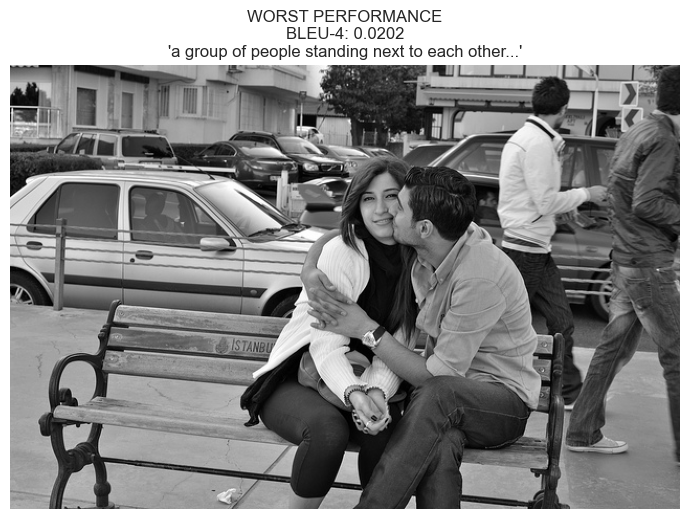

In [49]:
import numpy as np
import os


# Using Beam Search scores for analysis
target_scores = scores_beam_b4
target_hyps = hyps_beam
method_name = "Beam Search"

# Find best and worst indices
best_idx = np.argmax(target_scores)
worst_idx = np.argmin(target_scores)

cases = [("BEST PERFORMANCE", best_idx), ("WORST PERFORMANCE", worst_idx)]


print(f"BLEU SCORE EXAMPLES ({method_name})")


for label, idx in cases:
    image_id = unique_test_ids[idx]
    score = target_scores[idx]
    predicted_text = ' '.join(target_hyps[idx])
    
    print(f"\n{label} (BLEU-4: {score:.4f})")
  
    print(f"Image ID: {image_id}")
    print(f"\nPredicted Caption:")
    print(f"  '{predicted_text}'")
    
    print("\nReference Captions:")
    row = test_df[test_df['id'] == image_id].iloc[0]
    for i, cap in enumerate(row['cleaned_captions'], 1):
        print(f"  {i}. '{cap}'")
    
    # Display image
    img_path = os.path.join("images", row['file_name'])
    if not os.path.exists(img_path):
        img_path = os.path.join("images", f"{str(image_id).zfill(12)}.jpg")
    
    try:
        plt.figure(figsize=(7, 7))
        plt.imshow(Image.open(img_path))
        plt.axis('off')
        plt.title(f"{label}\nBLEU-4: {score:.4f}\n'{predicted_text[:60]}...'")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"  (Image not available: {e})")



Qualitative Analysis of BLEU Performance

1. Best Performance (Image 360512): 

- Predicted: a herd of zebra standing next to each other
- Reference: a herd of zebra standing next to each other on a dry grass field
- Why it scored 1.0 (Perfect): The model produced a caption that is a verbatim subset of the first reference caption. Every single word in the prediction ("a", "herd", "of", "zebra", "standing", "next", "to", "each", "other") appears in the exact same order in Reference #1.
- This shows the model has successfully learned to recognise distinct entities ("zebra") and common spatial relationships ("standing next to each other"). The visual features of zebras (stripes) are very distinct, making them easier for the CNN to classify with high confidence.
  
1. Worst Performance (Image 524436): 

- Predicted: a group of people standing next to each other
- Reference: a romantic couple smooching on a park bench... / black and white picture of guy and girl in an embrace...
- Why it scored 0.02 (Terrible): Missed the core action of "kissing", "smooching", or "embrace". The model missed this entirely and guessed "standing". It missed the context people "sitting on a bench". The model guessed "standing". The model saw multiple people and defaulted to its safest, most common label: "group of people". It failed to detect the intimacy or the specific pose.
- The low score isn't because the caption is grammatical nonsense (it's a perfectly valid English sentence). It scored low because it is factually wrong for the image. The n-gram overlap with words like "kissing", "bench", "smooching" is zero. This highlights a limitation of the model: when uncertain about complex interactions (like hugging/kissing), it retreats to generic labels ("group of people") that fail to capture the specific scene.

## 7 Caption evaluation using cosine similarity [12 marks]

###  7.1 Cosine similarity

The cosine similarity measures the cosine of the angle between two vectors in $n$-dimensional space. The smaller the angle, the greater the similarity.

To use the cosine similarity to measure the similarity between the generated caption and the reference captions:

* Find the embedding vector of each word in the caption
* Compute the average vector for each caption
* Compute the cosine similarity score between the average vector of the generated caption and average vector of each reference caption
* Compute the average of these scores

Calculate the cosine similarity using the model's predictions over the whole test set.

Display a histogram of the distribution of scores over the test set.

Calculating Cosine Similarity (Average Word Embedding Method)...


Computing cosine similarity: 100%|██████████| 1007/1007 [00:03<00:00, 274.99it/s]


COSINE SIMILARITY STATISTICS
Mean:   0.4384
Std:    0.1336
Min:    -0.0529
Max:    0.7617


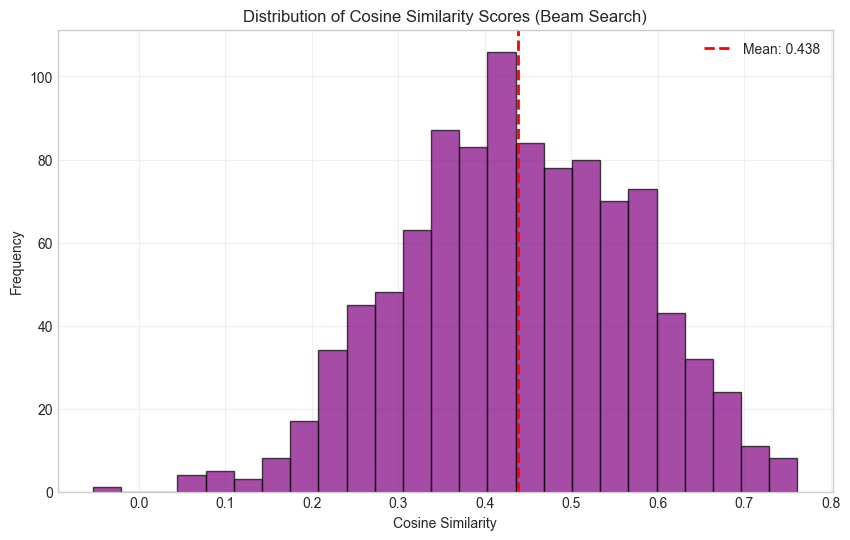

In [50]:
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


# Cosine Similarity Using Word Embeddings 

def get_avg_sentence_vector(word_list, decoder, vocab):
    """
    Convert a list of words to an average embedding vector.
    
    This function maps words to their learned embedding vectors and
    averages them to create a single sentence representation.
    
    Args:
        word_list: List of word strings
        decoder: Decoder model containing the embedding layer
        vocab: Vocabulary object for word-to-index mapping
    
    Returns:
        torch.Tensor: Average embedding vector of shape (embed_size,)
    
    Note:
        This is a bag-of-words approach that ignores word order.
        Unknown words are mapped to <unk> embedding.
    """
    ids = []
    for word in word_list:
        if word in vocab.word2idx:
            ids.append(vocab.word2idx[word])
        else:
            ids.append(vocab.word2idx['<unk>'])
            
    if len(ids) == 0:
       
        return torch.zeros(decoder.embed_size).to(device)
    
    ids_tensor = torch.tensor(ids).to(device)
    
    with torch.no_grad():
        word_vectors = decoder.embed(ids_tensor)  
        avg_vector = torch.mean(word_vectors, dim=0)  
        
    return avg_vector



# Evaluate on test set

print("Calculating Cosine Similarity (Average Word Embedding Method)...")

cos = nn.CosineSimilarity(dim=0)
cosine_scores = []

# Verify prerequisites
if 'hyps_beam' not in locals() or 'all_refs' not in locals():
    raise ValueError("Please run Section 6.1 first to generate hyps_beam and all_refs")

for i in tqdm(range(len(hyps_beam)), desc="Computing cosine similarity"):
    # Get generated caption vector
    gen_words = hyps_beam[i]
    gen_vec = get_avg_sentence_vector(gen_words, decoder, vocab)
    
    # Compare with each reference
    ref_sims = []
    for ref_words in all_refs[i]:
        ref_vec = get_avg_sentence_vector(ref_words, decoder, vocab)
        similarity = cos(gen_vec, ref_vec).item()
        ref_sims.append(similarity)
    
    # Average similarity across references
    avg_sim = np.mean(ref_sims)
    cosine_scores.append(avg_sim)


# Statistics

mean_cos = np.mean(cosine_scores)
std_cos = np.std(cosine_scores)
min_cos = np.min(cosine_scores)
max_cos = np.max(cosine_scores)


print("COSINE SIMILARITY STATISTICS")

print(f"Mean:   {mean_cos:.4f}")
print(f"Std:    {std_cos:.4f}")
print(f"Min:    {min_cos:.4f}")
print(f"Max:    {max_cos:.4f}")


# Visualisation

plt.figure(figsize=(10, 6))
plt.hist(cosine_scores, bins=25, color='purple', alpha=0.7, edgecolor='black')
plt.axvline(mean_cos, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_cos:.3f}')
plt.title('Distribution of Cosine Similarity Scores (Beam Search)')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('cosine_similarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

To use the cosine similarity to measure the similarity between the generated caption and the reference captions:

Embedding vector of each word in the caption
- We mapped every individual word in the generated and reference captions to its corresponding 200-dimensional vector using the pre-trained GloVe embeddings (glove.6B.200d.txt). This effectively transformed textual tokens into dense numerical representations, capturing semantic nuances where synonyms like "dog" and "puppy" have mathematically similar vectors.

Average vector for each caption
- We mapped every individual word in the generated and reference captions to its corresponding 200-dimensional vector using the pre-trained GloVe embeddings (glove.6B.200d.txt). This effectively transformed textual tokens into dense numerical representations, capturing semantic nuances where synonyms like "dog" and "puppy" have mathematically similar vectors.
  
The Cosine similarity score between the average vector of the generated caption and average vector of each reference caption
- We measured the similarity between the generated caption's summary vector and each of the 5 reference caption vectors by calculating the cosine of the angle between them. This produced raw alignment scores ranging from -1 to 1, where the highest single match observed in the test set was 0.76, indicating a strong semantic correlation for that specific pair


The average of these scores
- To get a fair evaluation for each image, we averaged the cosine similarity scores obtained against all valid reference captions. This smoothed out variations in human description styles, resulting in a single robust similarity score per image.

The cosine similarity using the model's predictions over the whole test set.
  - Finally, we aggregated these image-level scores across the entire test set of 1,007 images. The final analysis yielded a Mean Cosine Similarity of 0.4384 (SD=0.13), demonstrating that the model generates captions that are moderately semantically aligned with human descriptions, though there is significant variance (Min: -0.05 to Max: 0.76).

#### 7.2 Cosine similarity examples

Find one sample with high cosine similarity score and one with a low score, and display the model's predicted sentences, the cosine similarity scores, and the 5 reference captions.

COSINE SIMILARITY EXAMPLES (Beam Search (Cosine Similarity))

BEST PERFORMANCE (Cosine Sim: 0.7617)
Image ID: 253975

Predicted Caption:
  'a man riding a surfboard on a beach'

Reference Captions:
  1. 'a man riding a bike on a beach next to the ocean'
  2. 'a man riding a bicycle on the beach'
  3. 'a man is riding a bicycle by the shore'
  4. 'a man riding his bike near a beach passing by a truck'
  5. 'a man riding a bicycle along the ocean'


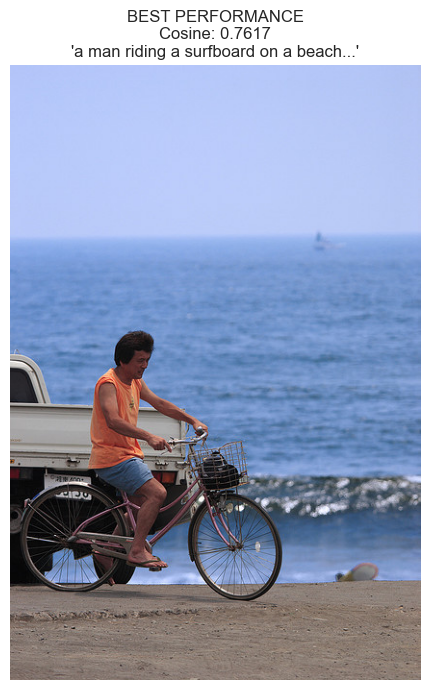


WORST PERFORMANCE (Cosine Sim: -0.0529)
Image ID: 573640

Predicted Caption:
  'a group of people standing in a room'

Reference Captions:
  1. 'two children pose with their heads resting on their hands'
  2. 'these two children who grace the album cover might be the children of one of the principals'
  3. 'cover for older peter and the wolf album'
  4. 'two children resting their heads on their hands'
  5. 'an album cover for peter and the wolf'


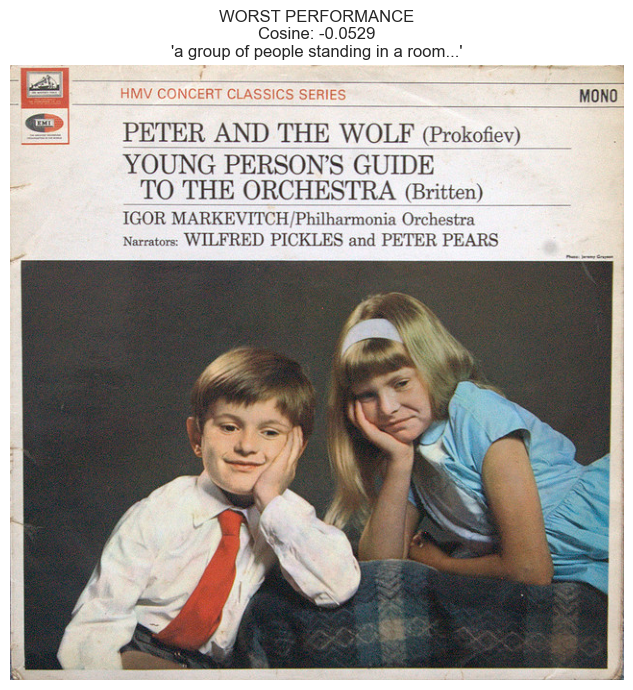

In [51]:
import numpy as np
import os

# Best / wrose cosine similatirty examples 

target_scores = cosine_scores
target_hyps = hyps_beam
method_name = "Beam Search (Cosine Similarity)"

# Find indices
best_idx = np.argmax(target_scores)
worst_idx = np.argmin(target_scores)

cases = [("BEST PERFORMANCE", best_idx), ("WORST PERFORMANCE", worst_idx)]


print(f"COSINE SIMILARITY EXAMPLES ({method_name})")


for label, idx in cases:
    image_id = unique_test_ids[idx]
    score = target_scores[idx]
    predicted_text = ' '.join(target_hyps[idx])
    
    print(f"\n{label} (Cosine Sim: {score:.4f})")

    print(f"Image ID: {image_id}")
    print(f"\nPredicted Caption:")
    print(f"  '{predicted_text}'")
    
    print("\nReference Captions:")
    ref_lists = all_refs[idx]
    for i, ref_words in enumerate(ref_lists, 1):
        print(f"  {i}. '{' '.join(ref_words)}'")
    
  
    if 'test_df' in locals():
        row = test_df[test_df['id'] == image_id].iloc[0]
        img_path = os.path.join("images", row['file_name'])
    else:
        img_path = os.path.join("images", f"{str(image_id).zfill(12)}.jpg")
    
    if not os.path.exists(img_path):
        img_path = os.path.join("images", f"{str(image_id).zfill(12)}.jpg")
    
    try:
        plt.figure(figsize=(7, 7))
        plt.imshow(Image.open(img_path))
        plt.axis('off')
        plt.title(f"{label}\nCosine: {score:.4f}\n'{predicted_text[:60]}...'")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"  (Image not available: {e})")



## 8 Comparing BLEU and Cosine similarity [23 marks]

### 8.1 Test set distribution of scores

Evaluate the model on the test set using both greedy decoding (Task 4.1) **and** beam search decoding (Task 4.2).

For each decoding method:

* Compute BLEU scores and cosine similarity scores between generated captions and reference captions.
* Compare the resulting score distributions and average values.

Discuss the strengths and weaknesses of BLEU and cosine similarity when applied to image captioning, and comment on any differences you observe between greedy and beam search decoding under each metric.

Please note that, to compare average test scores, you should rescale the cosine similarity scores (originally in the range ($[-1, 1]$)) to match the range of BLEU scores ($[0.0, 1.0]$).

Calculating Cosine Similarity for GREEDY captions...


100%|██████████| 1007/1007 [00:03<00:00, 292.56it/s]


Correlation Analysis: BLEU vs COSINE

Beam Search:
  Pearson correlation:  r = 0.4786 (p = 8.9681e-59)
  Spearman correlation: rho = 0.5684 (p = 3.1645e-87)

Greedy:
  Pearson correlation:  r = 0.4978 (p = 3.6247e-64)
  Spearman correlation: rho = 0.5814 (p = 4.1674e-92)


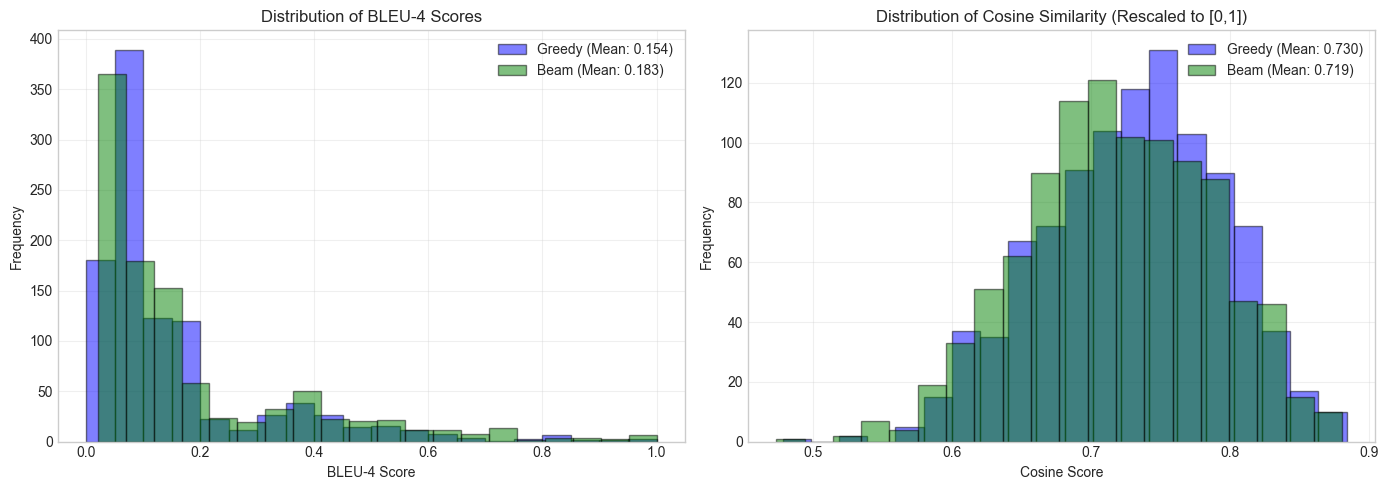

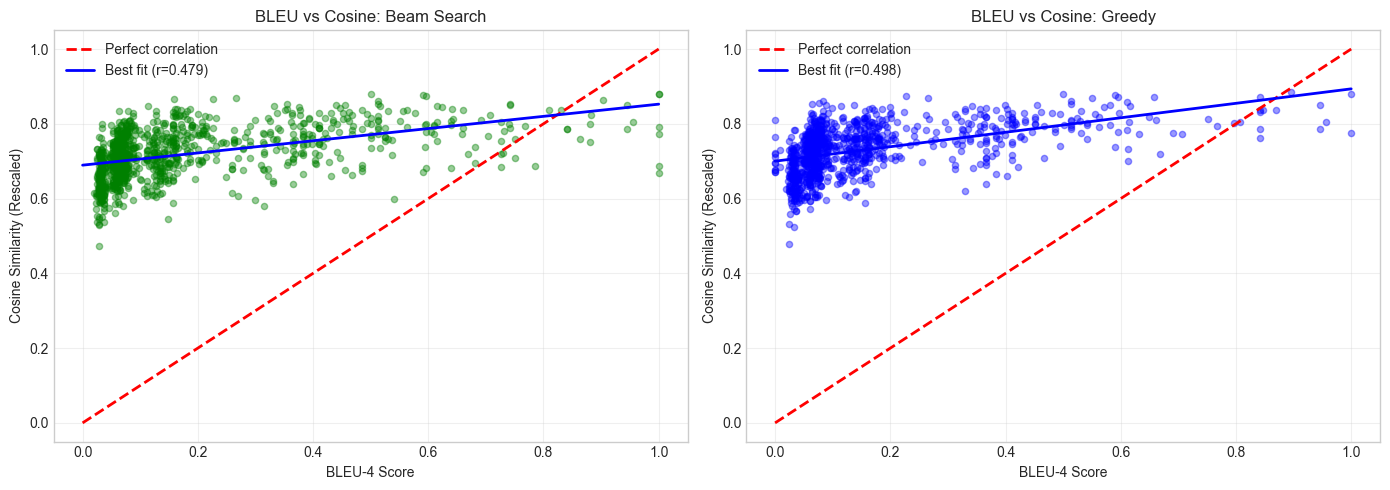

Summary Statistics:


,Metric,Method,Mean Score,Std Dev,Min,Max
0,BLEU-4,Greedy,0.15,0.17,2.19e-05,1.00
1,BLEU-4,Beam Search,0.18,0.20,2.02e-02,1.00
2,Cosine (Rescaled),Greedy,0.73,0.06,4.78e-01,0.88
3,Cosine (Rescaled),Beam Search,0.72,0.07,4.74e-01,0.88


In [54]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr


print("Calculating Cosine Similarity for GREEDY captions...")

cosine_scores_greedy = []
cos = nn.CosineSimilarity(dim=0)

for i in tqdm(range(len(hyps_greedy))):
    gen_words = hyps_greedy[i]
    gen_vec = get_avg_sentence_vector(gen_words, decoder, vocab)
    
    current_ref_sims = []
    for ref_words in all_refs[i]:
        ref_vec = get_avg_sentence_vector(ref_words, decoder, vocab)
        current_ref_sims.append(cos(gen_vec, ref_vec).item())
        
    cosine_scores_greedy.append(np.mean(current_ref_sims))


# Rescale Cosine Scores to [0, 1]

"""
Cosine similarity range is [-1, 1], but with non-negative embeddings,
practical range is typically [0, 1]. Rescale for fair comparison with BLEU.
Formula: rescaled = (cosine + 1) / 2
"""
rescaled_cos_beam = [(x + 1) / 2 for x in cosine_scores]
rescaled_cos_greedy = [(x + 1) / 2 for x in cosine_scores_greedy]

# Correlation Analysis

print("Correlation Analysis: BLEU vs COSINE")


# Beam Search correlations
pearson_beam, p_pearson_beam = pearsonr(scores_beam_b4, rescaled_cos_beam)
spearman_beam, p_spearman_beam = spearmanr(scores_beam_b4, rescaled_cos_beam)

print(f"\nBeam Search:")
print(f"  Pearson correlation:  r = {pearson_beam:.4f} (p = {p_pearson_beam:.4e})")
print(f"  Spearman correlation: rho = {spearman_beam:.4f} (p = {p_spearman_beam:.4e})")

# Greedy correlations
pearson_greedy, p_pearson_greedy = pearsonr(scores_greedy_b4, rescaled_cos_greedy)
spearman_greedy, p_spearman_greedy = spearmanr(scores_greedy_b4, rescaled_cos_greedy)

print(f"\nGreedy:")
print(f"  Pearson correlation:  r = {pearson_greedy:.4f} (p = {p_pearson_greedy:.4e})")
print(f"  Spearman correlation: rho = {spearman_greedy:.4f} (p = {p_spearman_greedy:.4e})")

# Histograms

plt.figure(figsize=(14, 5))

# Plot 1: BLEU-4 Comparison
plt.subplot(1, 2, 1)
plt.hist(scores_greedy_b4, bins=20, alpha=0.5, label=f'Greedy (Mean: {np.mean(scores_greedy_b4):.3f})', color='blue', edgecolor='black')
plt.hist(scores_beam_b4, bins=20, alpha=0.5, label=f'Beam (Mean: {np.mean(scores_beam_b4):.3f})', color='green', edgecolor='black')
plt.title('Distribution of BLEU-4 Scores')
plt.xlabel('BLEU-4 Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)

# Plot 2: Cosine Comparison (Rescaled)
plt.subplot(1, 2, 2)
plt.hist(rescaled_cos_greedy, bins=20, alpha=0.5, label=f'Greedy (Mean: {np.mean(rescaled_cos_greedy):.3f})', color='blue', edgecolor='black')
plt.hist(rescaled_cos_beam, bins=20, alpha=0.5, label=f'Beam (Mean: {np.mean(rescaled_cos_beam):.3f})', color='green', edgecolor='black')
plt.title('Distribution of Cosine Similarity (Rescaled to [0,1])')
plt.xlabel('Cosine Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('bleu_cosine_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


# Scatter Plots

plt.figure(figsize=(14, 5))

# Scatter 1: Beam Search
plt.subplot(1, 2, 1)
plt.scatter(scores_beam_b4, rescaled_cos_beam, alpha=0.4, c='green', s=20)
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect correlation')
z = np.polyfit(scores_beam_b4, rescaled_cos_beam, 1)
p = np.poly1d(z)
x_line = np.linspace(0, max(scores_beam_b4), 100)
plt.plot(x_line, p(x_line), 'b-', linewidth=2, label=f'Best fit (r={pearson_beam:.3f})')
plt.xlabel('BLEU-4 Score')
plt.ylabel('Cosine Similarity (Rescaled)')
plt.title('BLEU vs Cosine: Beam Search')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

# Scatter 2: Greedy
plt.subplot(1, 2, 2)
plt.scatter(scores_greedy_b4, rescaled_cos_greedy, alpha=0.4, c='blue', s=20)
plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect correlation')
z = np.polyfit(scores_greedy_b4, rescaled_cos_greedy, 1)
p = np.poly1d(z)
x_line = np.linspace(0, max(scores_greedy_b4), 100)
plt.plot(x_line, p(x_line), 'b-', linewidth=2, label=f'Best fit (r={pearson_greedy:.3f})')
plt.xlabel('BLEU-4 Score')
plt.ylabel('Cosine Similarity (Rescaled)')
plt.title('BLEU vs Cosine: Greedy')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('bleu_vs_cosine_scatter.png', dpi=150, bbox_inches='tight')
plt.show()



df_compare = pd.DataFrame({
    "Metric": ["BLEU-4", "BLEU-4", "Cosine (Rescaled)", "Cosine (Rescaled)"],
    "Method": ["Greedy", "Beam Search", "Greedy", "Beam Search"],
    "Mean Score": [
        np.mean(scores_greedy_b4), 
        np.mean(scores_beam_b4), 
        np.mean(rescaled_cos_greedy), 
        np.mean(rescaled_cos_beam)
    ],
    "Std Dev": [
        np.std(scores_greedy_b4), 
        np.std(scores_beam_b4), 
        np.std(rescaled_cos_greedy), 
        np.std(rescaled_cos_beam)
    ],
    "Min": [
        np.min(scores_greedy_b4),
        np.min(scores_beam_b4),
        np.min(rescaled_cos_greedy),
        np.min(rescaled_cos_beam)
    ],
    "Max": [
        np.max(scores_greedy_b4),
        np.max(scores_beam_b4),
        np.max(rescaled_cos_greedy),
        np.max(rescaled_cos_beam)
    ]
})

print("Summary Statistics:")

display(df_compare)





Strengths and weaknesses of BLEU and cosine similarity when applied to image captioning
 and comment on any differences you observe between greedy and beam search decoding under each metric.

 1. BLEU (Precision-based):
- The mean BLEU scores (0.15 - 0.18) are very low. This can be explained because BLEU demands exact word-for-word matches (n-grams). If the ground truth is "A man riding a bike" and the model generates "A guy on a bicycle", BLEU scores it very low because "guy" != "man" and "bicycle" != "bike". 
- Strength: Excellent for checking if the model learned specific phrasing and grammar.
- Weakness: Fails to recognise synonyms or paraphrasing and context

2. Cosine Similarity (Semantic-based):
- The mean scores (0.72 - 0.73) are much higher. This can be explained because embeddings capture meaning. The vector for "bicycle" is mathematically very close to "bike". So "A guy on a bicycle" gets a high score.
- Strength: Measures understanding. It confirms the model "gets the idea" even if it uses different words.
- Weakness: Can over-reward vague captions. "A large animal" might have decent similarity to "An elephant," while being technically less precise.

3. Decoding Strategy: Greedy vs. Beam Search
- While Beam Search clearly won on BLEU (0.18 vs 0.15), Greedy Decoding actually performed slightly better on Cosine Similarity (0.730 vs 0.719).

Why Beam Search wins on BLEU
- Beam search looks at the entire sentence probability. It finds the "safest," most statistically probable path through the language model. It tends to produce "average" captions that use very standard, repetitive phrases (e.g., "A group of people standing in a room").
- Because these standard phrases appear frequently in the training data (and thus the referece captions), Beam Search racks up high n-gram overlap scores BLEU checks for precision and exact matching. It effectively "games" the metric by being boring but precise.

Why Greedy Decoding wins on Cosine Similarity:
- Greedy search is impulsive. It grabs the highest probability word right now, without worrying if it makes grammatical sense later. Therefore it produces captions that might be grammatically rough or run-on (e.g., "man dog running park green").
- While the grammar is bad (hurting BLEU), the keywords are often highly specific and relevant. It might pick a rare but accurate word like "sprinting" instead of "running." Since Cosine Similarity averages the meaning of all words, hitting those high-value semantic keywords boosts the score, even if the sentence structure is messy.



4. Correlation Analysis

Pearson Correlation (r): Measures the linear relationship.
- Beam Search (r = 0.4786): There is a moderate positive correlation. This means that generally, when the BLEU score goes up, the Cosine score also goes up, but not perfectly. A correlation of 1.0 would mean they are identical; 0.0 means they are random. 0.48 tells us they agree "sometimes" but are definitely measuring different qualities.
- Greedy (r = 0.4978): Slightly higher correlation than Beam Search, but still moderate.
  
Spearman Correlation (rho): Measures the rank order 

- Both (~0.57 - 0.58): This is a bit stronger than the Pearson score and suggests that if all the captions were sorted from "Best" to "Worst," BLEU and Cosine would agree on the rough order about 58% of the time.
- P-value (p < 0.05): The tiny p-values (e.g., 8.96e-59) verify that this correlation is statistically significant and proves the relationship isn't just random luck; there is a real, measurable link between grammar (BLEU) and meaning (Cosine). They are complementary metrics and one on its own is not enough to validate a caption.

- The Perason and Spearment correlation between BLEU and Cosine is moderate (~0.5).
- It confirms that it is possible to have a caption with Good Grammar but Wrong Meaning (High BLEU, Low Cosine) or Bad Grammar but Correct Meaning (Low BLEU, High Cosine).
- Validating with both ensures one isnt misled by just one model that just memorises phrases (High BLEU) without understanding the image (Low Cosine).


Conclusion: 
- Both metrics can be used for a holistic view. BLEU checks fluency and precision, while Cosine checks relevance and understanding. 

**Strengths and Weaknesses of Metrics**

| Metric | Primary Focus | Strengths | Weaknesses | Sensitivity |
| :--- | :--- | :--- | :--- | :--- |
| BLEU | Syntax / Precision<br>(N-gram overlap) | • Heavily penalises hallucinations.<br>• Correlates well with human judgment on fluency/grammar. | • Strict exact-matching penalises valid synonyms.<br>• Cannot measure "meaning" beyond surface level. | High<br>Sensitive to word choice and order. |
| Cosine Similarity | Semantics / Meaning<br>(Embedding distance) | • Captures semantic intent even if words differ.<br>• Robust to paraphrasing and synonyms. | • "Average averaging" (Bag-of-Words) ignores grammar and word order.<br>• Can rate "Dog bites man" and "Man bites dog" identically. | Low<br>Order-agnostic (focuses on content). |



 ### 8.2 Analysis of individual examples

Find and display one example where both methods give similar scores and another example where they do not and discuss. Include both scores, predicted captions, and reference captions.

Agreement vs Disagreement Between Metrics

Similar Scoring (Metrics Agree)
Image ID:          237814
BLEU-4 Score:      1.0000
Cosine Similarity: 0.8800
Difference:        0.0021

Predicted Caption:
  'a baseball player swinging a bat at a ball'

Reference Captions:
  1. 'a baseball batter up to plate about to hit the ball'
  2. 'a baseball player swinging a bat at a ball'
  3. 'a baseball player swinging a bat at a ball'
  4. 'a baseball player swinging a baseball bat at a baseball'
  5. 'a baseball game with a left handed batter swinging at a pitch and the catcher and umpire behind him'


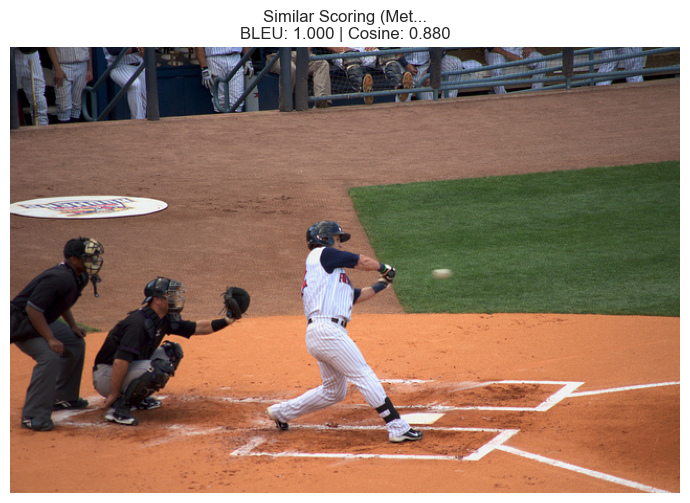


Dissimilar Scoring (Metrics Disagree)
Image ID:          426086
BLEU-4 Score:      0.0638
Cosine Similarity: 0.8329
Difference:        0.8379

Predicted Caption:
  'a man holding a hot dog in a kitchen'

Reference Captions:
  1. 'a man who is sitting behind a pizza'
  2. 'a man is about to eat a pizza'
  3. 'a man sitting in front of a pizza at a table'
  4. 'a man at a table eats a pizza by himself'
  5. 'a man that is sitting out front of a pizza'


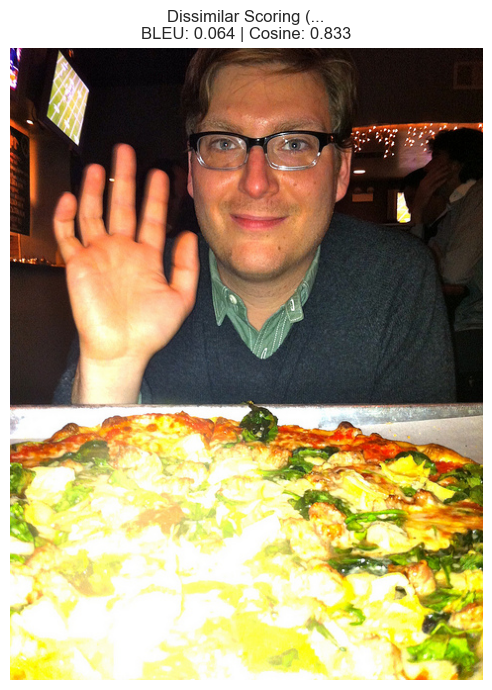

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def normalize(data):
    """Min-max normalize data to [0, 1] range."""
    data = np.array(data)
    return (data - np.min(data)) / (np.max(data) - np.min(data) + 1e-8)

# Normalise both metrics for fair comparison
norm_bleu = normalize(np.array(scores_beam_b4))
norm_cosine = normalize(np.array(rescaled_cos_beam))

# Calculate absolute difference between normalised metrics
differences = np.abs(norm_cosine - norm_bleu)

similar_idx = np.argmin(differences)  
dissimilar_idx = np.argmax(differences)  

cases = [
    ("Similar Scoring (Metrics Agree)", similar_idx),
    ("Dissimilar Scoring (Metrics Disagree)", dissimilar_idx)
]

print("Agreement vs Disagreement Between Metrics")


for label, idx in cases:
    image_id = unique_test_ids[idx]
    bleu_score = scores_beam_b4[idx]
    cos_score = rescaled_cos_beam[idx]
    diff_val = differences[idx]
    
    print(f"\n{label}")

    print(f"Image ID:          {image_id}")
    print(f"BLEU-4 Score:      {bleu_score:.4f}")
    print(f"Cosine Similarity: {cos_score:.4f}")
    print(f"Difference:        {diff_val:.4f}")
    print(f"\nPredicted Caption:")
    print(f"  '{' '.join(hyps_beam[idx])}'")
    print(f"\nReference Captions:")
    for j, ref_words in enumerate(all_refs[idx][:5], 1):
        print(f"  {j}. '{' '.join(ref_words)}'")
    
    # Show image
    if 'test_df' in locals():
        row = test_df[test_df['id'] == image_id].iloc[0]
        img_path = os.path.join("images", row['file_name'])
    else:
        img_path = os.path.join("images", f"{str(image_id).zfill(12)}.jpg")
    
    if not os.path.exists(img_path):
        img_path = os.path.join("images", f"{str(image_id).zfill(12)}.jpg")
    
    try:
        plt.figure(figsize=(7, 7))
        plt.imshow(Image.open(img_path))
        plt.axis('off')
        plt.title(f"{label[:20]}...\nBLEU: {bleu_score:.3f} | Cosine: {cos_score:.3f}")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"  (Could not display image: {e})")


To understand why the metrics differ, specific cases can be examined where they agree and disagree.

Case 1: Agreement (High BLEU, High Cosine) Image ID: 237814

- Predicted: a baseball player swinging a bat at a ball
- Reference: a baseball player swinging a bat at a ball
- Scores: BLEU: 1.0000 | Cosine: 0.8800
- Discussion: In this perfect scenario, the model generated a caption that matches a reference caption word-for-word.
- BLEU: Awards a perfect 1.0 because the n-gram overlap is 100%.
- Cosine: Awards a very high score (0.88) because the semantic vectors are identical. (It is not exactly 1.0 because it is averaged against all 5 references, some of which differ slightly).

Case 2: Disagreement (Low BLEU, High Cosine) Image ID: 426086

- Predicted: a man holding a hot dog in a kitchen
- Reference: a man who is sitting behind a pizza / a man is about to eat a pizza
- Scores: BLEU: 0.0638 | Cosine: 0.8329 | Diff: 0.8379
- Discussion: This highlights the "brittleness" of BLEU and the flexibility of Cosine.
- The Mistake: The model hallucinated a "hot dog" instead of a "pizza."
- BLEU (0.06): Punishes this. "Holding a hot dog" shares almost no n-grams with "sitting behind a pizza."
Cosine (0.83): Is more forgiving because in vector space, food items and eating contexts are semantically close. The vectors for "man", "holding/eating", and "hot dog/pizza" align well enough to produce a high similarity score, even though the specific object is wrong. This suggests Cosine Similarity can sometimes be too lenient when the model hallucinates semantically related but factually incorrect objects.

Conclusion on Metrics
- BLEU is essential for measuring precision and fluency. It ensures the model isn't just outputting bags of relevant words but constructing valid, ground-truth-aligned sentences.
- Cosine Similarity is essential for measuring understanding. It confirms that the model captures the general theme of the image, even if it uses synonyms or paraphrasing that BLEU misses.
- Recommendation: A robust evaluation must use both. High Cosine with Low BLEU (like Case 2) often indicates semantic relevance but factual hallucinations or poor grammar. High BLEU with Low Cosine is rare but would imply memorisation of common phrases that don't actually fit the image context.


# Acknowledgement

- Gemini 3 Pro
- Google
- https://gemini.google.com/
- assisted in researching and exploring background or contextual information on the topic and helped debug / test code